# QAD recovery curves (vLLM evals)

Parses `qad/results/vllm/think/` and `qad/results/vllm/nothink/` and plots
benchmark accuracy vs QAD training step
for each quantization method, with the full-precision BF16 baseline as a horizontal line.

The grid has **one row per model size** (Qwen3-0.6B / 1.7B / 4B) and **one column per
benchmark**, plus a final **Average** column. The average covers exactly the benchmarks
left uncommented in `TASKS` (so commenting out e.g. AIME-2025 removes it from both the
panels and the mean), and is only plotted at steps where every one of them has a value.
Each model's own BF16 baseline is drawn per cell; methods share a color across the whole
grid (single legend on top).

**Thinking mode is part of the benchmark.** Qwen3 scores ~20 points higher on GSM8K
with thinking enabled, so each benchmark appears once per mode as its own column,
labelled `[think]` / `[no-think]`. **Disaggregated serving is the reported number.** Each point comes from
`results/disagg/*` when available; a single-engine value fills the hole
otherwise, drawn as a **hollow marker**. The loader prints the disagg/single
split so a partially-filled sweep is never mistaken for a finished one.

> Everything under `results/vllm/think/` was produced with thinking ON — including
> runs whose command line said `--no-think`. `eval_vllm.py` patched the chat template with
> `setdefault`, which never took effect, so those runs are mislabelled at the source. The
> script now forces the kwarg and asserts the rendered prompt actually changed. Do not
> compare numbers across the two trees.


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Original six, unchanged.
RED    = "#cd001a"
ORANGE = "#ef6a00"
YELLOW = "#f2cd00"
GREEN  = "#79c300"
BLUE   = "#1961ae"
PURPLE = "#61007d"
# Extensions, same flat saturated register.
PINK   = "#e5006d"
BROWN  = "#8a5a2b"
OLIVE  = "#6b8f00"
TEAL   = "#00a19a"
FOREST = "#1f7a33"
NAVY   = "#0b2d6b"
GREY   = "#6e6e6e"
SKY    = "#3fa9f5"   # 2-bit family: distinct from BLUE (lloyd21) and NAVY
CYAN   = "#00b8d4"   # 2-bit NVR decode, upcast family
INDIGO = "#534bae"   # 2-bit NVR decode, split family

# COLOUR MEANS DECODE-SIDE WEIGHT PRECISION -- the half that dominates memory in
# deployment, and the axis every one of these formats is actually trading along. Hue
# runs warm -> green -> cool as the decode weight gets smaller:
#
#   4-bit decode   RED ORANGE PINK BROWN     NVFP4 everywhere, or NVFP4 both halves
#   3-bit decode   OLIVE GREEN TEAL FOREST   a Lloyd/LUT3 decode half
#   2-bit decode   BLUE NAVY PURPLE          a Lloyd/LUT2 decode half
#   BF16 half      YELLOW GREY               phase-isolation diagnostics, NOT deployable
#
# So a figure reads at a glance: warm curves buy speed, cool curves buy memory, and
# neutral curves are not shippable. Linestyle carries the orthogonal axis (solid/round =
# homogeneous, dashed/star = disaggregated), which is why a colour may repeat ACROSS that
# divide -- lloyd3bit and nvfp4lloyd43split share OLIVE, but one is solid and one dashed.
# Within a single style group in a single figure, colours are unique; the assertion below
# checks that against the figures actually drawn.

# Style is (label, colour, linestyle, marker). LINESTYLE AND MARKER CARRY THE ONE
# DISTINCTION THAT MATTERS MOST, so it survives greyscale, small panels and colour-blind
# readers:
#   solid + round  ->  ONE format everywhere (homogeneous)
#   dashed + star  ->  a DISAGGREGATED format (prefill and decode differ)
# Colour then separates methods WITHIN a figure. There are 11 methods and 6 palette
# colours, so colours are REUSED across figures -- the invariant is that no two methods
# drawn in the SAME plot_grid call share one. Check that when adding a method here.

# Thinking mode is a BENCHMARK DIMENSION, not a footnote: the same checkpoint scores
# ~20 points apart on GSM8K with and without it. The two live in separate trees so they
# can never be silently mixed (everything under results/vllm/think/ was produced
# with thinking on, including runs whose command line said --no-think — see that
# directory's README). Comment out a mode to drop it from the grid.
# Two independent axes, flattened into one "mode" key: THINKING (Qwen3 <think> blocks)
# and SERVING (one engine, vs a real disaggregated prefill/decode pair exchanging KV).
# Disaggregated is the deployment-accurate measurement, so it is a first-class series
# here rather than a footnote -- run_eval_disagg.sh writes the identical on-disk layout.
# DISAGGREGATED IS THE REPORTED NUMBER. Single-engine results are only a POINT-WISE
# fallback: for each (model, method, benchmark, step) the disaggregated value is used
# when it exists, and the single-engine value fills the hole otherwise. That keeps a
# curve continuous while the disagg sweep is still filling in, without ever discarding
# a disaggregated point in favour of a single-engine one.
#
# Sources are listed in PRIORITY ORDER per thinking mode.
SOURCES = {
    "think":   [("disagg", Path("../qad/results/disagg/think")),
                ("single", Path("../qad/results/vllm/think"))],
    "nothink": [("disagg", Path("../qad/results/disagg/nothink")),
                ("single", Path("../qad/results/vllm/nothink"))],
}
MODE_LABEL = {"think": "think", "nothink": "no-think"}
MODES = [m for m, srcs in SOURCES.items() if any(d.exists() for _, d in srcs)]

# Which training recipe to plot. Checkpoint tags are <RUN>-<model>-<method>-<hash>,
# so this switches between the two sets of runs. Uncomment exactly one.
RUN = "qad3x"    # 30M tokens, constant 3e-6 LR after 100-step warmup
# RUN = "qad"    # 10M tokens, cosine decay

# task -> (display title, preferred metric key). Metric keys vary by task filter:
#   - math500          : symbolic math_verify,none
#   - mmlu_flan_cot_*   : CoT generative MMLU; a GROUP whose top-level row is empty —
#                         the metric lives on 57 subject leaves (exact_match,flexible-extract),
#                         so get_metric() sample-weight-aggregates the leaves.
#   - mmlu_pro         : CoT; aggregates at the group level as exact_match,custom-extract.
# Comment a row out to drop it from the panels AND from the mean-recovery panel.
BENCHMARKS = {
    "gsm8k":                  ("GSM8K",      "exact_match,flexible-extract"),
    "minerva_math500":        ("MATH-500",   "math_verify,none"),
    # "aime25":                 ("AIME-2025",  "exact_match,none"),
    # "mmlu_flan_cot_zeroshot": ("MMLU (CoT)", "exact_match,flexible-extract"),
    "mmlu_pro":               ("MMLU-Pro",   "exact_match,custom-extract"),
}

# One plotted column per (benchmark, thinking mode). Keys are "<task>@<mode>" so the
# rest of the notebook needs no change; only modes actually present on disk appear.
TASKS = {
    f"{task}@{mode}": (f"{title} [{MODE_LABEL[mode]}]", key)
    for task, (title, key) in BENCHMARKS.items()
    for mode in MODES
}

# quantizer -> (legend label, colour, linestyle, marker). Plot order follows this dict.
# Comment a row out to hide that method; any method found on disk but missing here is
# reported by the warning below and simply not plotted.
#
# A key may be either "<method>" or "<method>-<hash>". The hash-qualified form wins
# when both are present, and is how you separate several runs of the SAME method that
# differ only in hyperparameters (the hash is over the quantizer params). Without it
# every arm of a sweep collapses onto one label/color — see the collision warning.
METHODS = {
    # --- homogeneous: one format on both phases (solid, round) ---------------
    "nvfp4":     ("NVFP4", RED, "-", "o"),
    "nvfp4a16":  ("NVFP4A16", ORANGE, "-", "o"),
    "lloyd3bit": ("W3A16 LLOYD", OLIVE, "-", "o"),
    # Same layer/grid family as lloyd3bit, on the LUT that pins 0.0 and +6.0 -- exact
    # block outlier and a real flush-to-zero, at ~3% higher Gaussian MSE. Its own tag
    # (42a1cbfd), so it plots against lloyd3bit rather than replacing it.
    "lloyd43":   ("LUT3", GREEN, "-", "o"),
    "lloyd21":   ("LUT2", BLUE, "-", "o"),
    # Homogeneous 2-bit like lloyd21, different codebook: a vector/LUT search
    # instead of a scalar grid. Same cool family (2-bit decode), own hue.
    "nvr2bit":   ("NVR2BIT", SKY, "-", "o"),

    # --- disaggregated: prefill and decode differ (dashed, star) -------------
    # NVFP4 (W4A4) prefill + NVFP4A16 (W4A16) decode. On the SAME axes as the
    # homogeneous formats -- the question is whether the mixed format beats running one
    # format everywhere, and that is only readable if the curves share a panel.
    "nvfp4pdshared": ("NVFP4/NVFP4A16", PINK, "--", "*"),
    "nvfp4pdsplit":  ("NVFP4+NVFP4A16", BROWN, "--", "*"),

    # PHASE-ISOLATION ABLATION -- diagnostics, not deployable formats. Each quantizes
    # exactly ONE phase and leaves the other in BF16, which isolates where NVFP4 hurts.
    # Named for the phase that runs NVFP4. A BF16 phase needs BF16 weights resident, so
    # neither is a candidate; they bound the pd formats from the "only one phase pays"
    # side the way NVFP4/NVFP4A16 bound them from the homogeneous side.
    "nvfp4prefill":  ("NVFP4 prefill only (BF16 decode)", YELLOW, "--", "*"),
    "nvfp4decode":   ("NVFP4 decode only (BF16 prefill)", GREY, "--", "*"),

    # NVFP4 W4A4 prefill + Lloyd43 W3A16 decode: each phase gets the format its
    # bottleneck wants. Deployable (both halves are genuinely low-precision), unlike the
    # phase-isolation diagnostics above. Bounded by nvfp4 (4-bit everywhere) and
    # lloyd43 (3-bit weight-only everywhere) -- see the comparison cell below.
    "nvfp4lloyd43shared": ("NVFP4/LUT3 common", FOREST, "--", "*"),
    "nvfp4lloyd43split":  ("NVFP4+LUT3", OLIVE, "--", "*"),
    "nvfp4lloyd21split":  ("NVFP4+LUT2", PURPLE, "--", "*"),

    # Same two halves, but prefill is DERIVED from decode: the master is quantized
    # to Lloyd43 and THAT is re-quantized to NVFP4, so only the 3-bit weight has to
    # be stored. Its reference is nvfp4lloyd43shared -- same halves, independent
    # quantizations -- and the gap between them is the cost of the upcast.
    "nvfp4lloyd43upcast": ("NVFP4/LUT3", TEAL, "--", "*"),
    "nvfp4lloyd21upcast": ("NVFP4/LUT2", NAVY, "--", "*"),
    # Same two halves, NVR2BIT (2-bit vector LUT) decode instead of Lloyd2.
    "nvfp4nvr2bitupcast": ("NVFP4/NVR2BIT", CYAN, "--", "*"),
    "nvfp4nvr2bitsplit":  ("NVFP4+NVR2BIT", INDIGO, "--", "*"),

    # GSQ
    # "gsqlloyd3bit-34a2e5a5": ("GSQ LLOYD W3A16, logit_lr=3e-5", "tab:red"),
    # "gsqlloyd3bit-113e0057": ("GSQ LLOYD W3A16, logit_lr=1e-4", "tab:orange"),
    # "gsqlloyd3bit-28a6f8d3": ("GSQ LLOYD W3A16, logit_lr=3e-4", "tab:brown"),
    # "gsqlloyd3bit-2c7917b8": ("GSQ LLOYD W3A16, logit_lr=1e-5", "tab:cyan"),
    # "gsqlloyd3bit-c96c7cae": ("GSQ LLOYD W3A16, logit_lr=3e-6", "tab:olive"),
    # "gsqlloyd3bit-bcb432c4": ("GSQ LLOYD W3A16, logit_lr=1e-5, capped", "tab:pink"),
    # "gsqlloyd3bit-0a6afc4d": ("GSQ LLOYD W3A16, logit_lr=3e-6, capped", "tab:gray"),

    # Extra
    # "ste4bit":  ("W4A4 INT4 GS128",     "tab:orange"),
    # "ste3bit":  ("STE 3-bit",     "tab:red"),
    # "ste2bit":  ("STE 2-bit",     "tab:brown"),
    # "quest4bit":("QuEST 4-bit",   "tab:purple"),
    # "quest3bit":("QuEST 3-bit",   "tab:brown"),
    # "quest2bit":("QuEST 2-bit",   "tab:pink"),
    # "fp8":      ("FP8",           "tab:gray"),
}


def _leaf_metric(m, key):
    if key in m:
        return m[key]
    for k, v in m.items():
        if k.startswith(("exact_match,", "math_verify,")) and not k.endswith("_stderr"):
            return v
    return None


def get_metric(doc, task, key):
    results = doc.get("results", {})
    r = results.get(task, {})
    # 1) direct metric on the task / group aggregate row
    v = _leaf_metric(r, key)
    if v is not None:
        return v
    # 2) group with an empty top-level row: sample-weighted mean over subject leaves
    #    (keys like "<task>_abstract_algebra"; excludes "<task>::category" mid-groups).
    num = den = 0.0
    for t, m in results.items():
        if t == task or not t.startswith(task + "_"):
            continue
        lv = _leaf_metric(m, key)
        if lv is None:
            continue
        w = m.get("sample_len") or 1
        num += lv * w
        den += w
    return num / den if den else None


def load_tag(tag_dir, mode):
    """Return {"<task>@<mode>": {step: accuracy_pct}} for one checkpoint-tag directory."""
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        step = int(m.group(1))
        doc = json.loads(jf.read_text())
        for task, (_title, key) in BENCHMARKS.items():
            v = get_metric(doc, task, key)
            if v is not None:
                out.setdefault(f"{task}@{mode}", {})[step] = float(v) * 100.0
    return out


# Tag conventions (from eval_vllm.py):
#   method   : qad-<Model>-<quantizer>-<8hexhash>     e.g. qad-Qwen-Qwen3-4B-nvfp4-99914b93
#   baseline : <Model>-unquantized                    e.g. Qwen-Qwen3-1.7B-unquantized
# <Model> is e.g. Qwen-Qwen3-0.6B / Qwen-Qwen3-1.7B / Qwen-Qwen3-4B.
# The hash is captured too, so METHODS can key on "<method>-<hash>" (see above).
_METHOD_RE = re.compile(rf"^{RUN}-(Qwen-Qwen3-[^-]+)-([A-Za-z0-9.]+)-([0-9a-f]{{8}})$")
_BASELINE_RE = re.compile(r"^(Qwen-Qwen3-[^-]+)-unquantized$")

models = {}      # model -> {key -> {task -> {step -> acc_pct}}}   key: method or method-hash
baselines = {}   # model -> {task -> acc_pct}  (BF16, unquantized)
seen_hashes = {}  # method -> {hash} — to detect arms sharing one un-qualified key

FALLBACK = set()      # (model, key, "<task>@<mode>", step) filled from single-engine
SRC_COUNT = {}        # source -> number of points contributed


def _merge_points(dst, data, src, owner):
    """Insert only steps that are still missing, and record where each point came from.

    Priority is by source ORDER, not by file time: a later single-engine read must
    never displace a disaggregated point already in place.
    """
    for task, steps in data.items():
        cur = dst.setdefault(task, {})
        for step, val in steps.items():
            if step in cur:
                continue
            cur[step] = val
            SRC_COUNT[src] = SRC_COUNT.get(src, 0) + 1
            if src != "disagg" and owner is not None:
                FALLBACK.add((*owner, task, step))


for mode in MODES:
  for src, root in SOURCES[mode]:
    if not root.exists():
        continue
    for tag_dir in sorted(root.glob("*")):
        if not tag_dir.is_dir():
            continue
        data = load_tag(tag_dir, mode)
        if not data:
            continue
        mb = _BASELINE_RE.match(tag_dir.name)
        mm = _METHOD_RE.match(tag_dir.name)
        if mb:
            model = mb.group(1)
            bl = baselines.setdefault(model, {})
            for task, steps in data.items():
                if steps and task not in bl:      # first source wins (disagg)
                    bl[task] = steps[min(steps)]
        elif mm:
            model, method, qhash = mm.group(1), mm.group(2), mm.group(3)
            # hash-qualified key wins when listed; otherwise all hashes share one key
            key = f"{method}-{qhash}" if f"{method}-{qhash}" in METHODS else method
            seen_hashes.setdefault(method, set()).add(qhash)
            _merge_points(models.setdefault(model, {}).setdefault(key, {}),
                          data, src, (model, key))


def _size(model):  # sort key: 0.6 < 1.7 < 4
    m = re.search(r"Qwen3-([\d.]+)B", model)
    return float(m.group(1)) if m else 1e9


MODEL_ORDER = sorted(models, key=_size)

# Methods to plot: METHODS order, restricted to those actually present on disk.
found = {q for m in models.values() for q in m}
PLOT_METHODS = [q for q in METHODS if q in found]
unlisted = sorted(found - set(METHODS))
if unlisted:
    # suggest the hash-qualified name so it can be pasted straight into METHODS
    sugg = [f"{q}-{sorted(seen_hashes.get(q, {'?'}))[0]}" if len(seen_hashes.get(q, ())) > 1
            else q for q in unlisted]
    print(f"WARNING: results found for method(s) missing from METHODS — NOT plotted: "
          f"{unlisted}. Add them to METHODS to include them (e.g. {sugg}).")
missing = [q for q in METHODS if q not in found]
if missing:
    print(f"note: METHODS entries with no results on disk: {missing}")
# Several hyperparameter arms silently overwriting each other is the failure this
# guards: they'd share one label, one color, and only the last one read would survive.
for method, hashes in sorted(seen_hashes.items()):
    if len(hashes) > 1 and method in found:
        print(f"WARNING: {method!r} has {len(hashes)} hashes on disk {sorted(hashes)} but is "
              f"keyed WITHOUT a hash — only one arm is plotted. Replace the {method!r} entry "
              f"in METHODS with one '{method}-<hash>' entry per arm.")

print(f"run     : {RUN}   modes: {MODES}")
# Say plainly how much of the plot is actually disaggregated. A silently mixed figure
# is the failure this guards against.
_tot = sum(SRC_COUNT.values()) or 1
print("source  : " + ", ".join(f"{k}={v} ({100*v/_tot:.0f}%)"
                               for k, v in sorted(SRC_COUNT.items())))
if FALLBACK:
    print(f"          {len(FALLBACK)} point(s) fell back to single-engine "
          f"(drawn as hollow markers)")
print("models  :", {m.replace("Qwen-", ""): sorted(models[m]) for m in MODEL_ORDER})
print("plotting:", PLOT_METHODS)
print("baselines:", {m.replace("Qwen-", ""): {t: round(v, 1) for t, v in b.items()}
                     for m, b in baselines.items()})

run     : qad3x   modes: ['think', 'nothink']
source  : disagg=3846 (89%), single=495 (11%)
          495 point(s) fell back to single-engine (drawn as hollow markers)
models  : {'Qwen3-0.6B': ['gsqlloyd3bit', 'lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit', 'ste4bit'], 'Qwen3-1.7B': ['lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd43shared', 'nvfp4lloyd43split', 'nvfp4lloyd43upcast', 'nvfp4nvr2bitsplit', 'nvfp4nvr2bitupcast', 'nvfp4pdshared', 'nvfp4pdsplit', 'nvfp4prefill', 'nvr2bit', 'ste3bit', 'ste4bit'], 'Qwen3-4B': ['lloyd21', 'lloyd3bit', 'lloyd43', 'nvfp4', 'nvfp4a16', 'nvfp4decode', 'nvfp4lloyd21split', 'nvfp4lloyd21upcast', 'nvfp4lloyd43shared', 'nvfp4lloyd43spl

In [2]:
# Clear message instead of an opaque "Number of rows must be a positive integer"
# from plt.subplots() when the selected RUN has no eval results yet.
assert MODEL_ORDER, (f"No eval results for RUN={RUN!r} yet "
                     "- evals may still be queued; flip the RUN toggle above.")

import numpy as np

tasks = list(TASKS)                 # only the benchmarks left uncommented in TASKS
AVG = "__avg__"                     # synthetic panel: mean accuracy over those benchmarks
BARS = "__bars__"                   # synthetic panel: tail-averaged accuracy, bootstrapped
MIN_STEP = 250


TAIL_N = 5
N_BOOT = 20000
BOOT_SEED = 0                       # fixed so the figure is reproducible run to run


def avg_accuracy(curves, bl):
    """Mean accuracy over the plotted benchmarks: mean_t(acc_t).

    Simple average of raw scores. Only steps where EVERY plotted benchmark has a
    value are averaged, so a partially-failed sweep can't make the curve jump.
    Returns ({step: pct}, skipped).
    """
    usable = [t for t in tasks if t in curves and bl.get(t)]   # needs a non-zero baseline
    if len(usable) < len(tasks):
        return {}, sorted({s for t in usable for s in curves[t]})
    complete = set.intersection(*(set(curves[t]) for t in tasks))
    skipped = set().union(*(set(curves[t]) for t in tasks)) - complete
    return ({s: sum(curves[t][s] for t in tasks) / len(tasks)
             for s in complete}, sorted(skipped))


def _bl_avg(bl_all):
    """BF16 average accuracy over all plotted benchmarks, or None if any is missing."""
    vals = [bl_all.get(t) for t in tasks]
    return sum(vals) / len(vals) if all(v is not None for v in vals) else None


def tail_stats(curve, rng):
    """(mean, 2sigma) of the last TAIL_N points of a curve, bootstrapped.

    The bootstrap resamples the tail STEPS, so it measures how much a method wanders
    across late checkpoints. It is NOT evaluation uncertainty: every step is scored on
    the same problems, so their errors are correlated and this interval neither
    contains nor replaces the binomial stderr of a single measurement.
    """
    steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
    vals = np.array([curve[s] for s in steps], dtype=float)
    if vals.size == 0:
        return None
    if vals.size == 1:
        return float(vals[0]), 0.0, 1
    draws = rng.choice(vals, size=(N_BOOT, vals.size), replace=True).mean(axis=1)
    return float(vals.mean()), float(2.0 * draws.std(ddof=0)), int(vals.size)


def plot_grid(methods, outfile):
    """One row per model; columns = benchmarks, mean accuracy, then the tail bars.

    The bootstrapped bars live in the SAME figure as the curves they summarise, as the
    rightmost column, so a method's plateau is read off the same row as its trajectory
    instead of a separate figure the reader has to align by hand.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"
    panels = tasks + [AVG, BARS]
    rng = np.random.default_rng(BOOT_SEED)
    nrows, ncols = len(MODEL_ORDER), len(panels)
    # The bars column carries no x axis and at most a handful of bars, so give it half
    # the width of a curve panel rather than letting it stretch to match.
    widths = [1.0] * (ncols - 1) + [0.55]
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.8 * sum(widths), 3.7 * nrows),
                             squeeze=False, sharex=False, sharey=None,
                             gridspec_kw={"width_ratios": widths})
    skipped_note, short = {}, []

    for i, model in enumerate(MODEL_ORDER):
        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all)
        for j, panel in enumerate(panels):
            ax = axes[i][j]

            if panel == BARS:
                # tail of the AVG curve, one bar per method
                stats = {}
                for method in methods:
                    curve, _ = avg_accuracy(models[model].get(method, {}), bl_all)
                    st = tail_stats(curve, rng) if curve else None
                    if st:
                        stats[method] = st
                cfgs = [m for m in methods if m in stats]
                if cfgs:
                    means = [stats[m][0] for m in cfgs]
                    errs = [stats[m][1] for m in cfgs]
                    # hatch carries the same homogeneous/disaggregated split the
                    # linestyle carries on the curves -- a bar has no linestyle.
                    ax.bar(range(len(cfgs)), means, color=[METHODS[m][1] for m in cfgs],
                           hatch=["" if METHODS[m][2] == "-" else "//" for m in cfgs],
                           width=0.68, yerr=errs, capsize=3,
                           error_kw=dict(elinewidth=1.2, ecolor="0.25"))
                    for x, (m_, e_) in enumerate(zip(means, errs)):
                        ax.annotate(f"{m_:.1f}", xy=(x, m_ + e_), ha="center",
                                    va="bottom", fontsize=8)
                    bl_ref = bl_avg_val if bl_avg_val is not None else 0.0
                    lo = min([m_ - e_ for m_, e_ in zip(means, errs)] + [bl_ref])
                    hi = max([m_ + e_ for m_, e_ in zip(means, errs)] + [bl_ref])
                    pad = 0.12 * (hi - lo) if hi > lo else 1.0
                    ax.set_ylim(max(0, lo - pad), hi + pad)
                    short += [(model, m, stats[m][2]) for m in cfgs if stats[m][2] < TAIL_N]
                if bl_avg_val is not None:
                    ax.axhline(bl_avg_val, ls="--", color="0.4", lw=1.3)
                    ax.annotate(f"BF16 {bl_avg_val:.1f}%",
                                xy=(0.98, bl_avg_val),
                                xycoords=("axes fraction", "data"), ha="right", va="bottom",
                                fontsize=7, color="0.4")
                # no x labels: the bars are colour-keyed to the shared legend, and a
                # narrow panel cannot fit the method names legibly
                ax.set_xticks([])
                if i == 0:
                    ax.set_title("Avg accuracy", fontweight="bold")
                ax.set_ylabel("avg accuracy (%)", fontsize=9)
                ax.yaxis.set_label_position("right")
                ax.grid(True, axis="y", alpha=0.3)
                ax.set_axisbelow(True)
                continue

            for method in methods:                 # METHODS order, only what's on disk
                label, color, ls, mk = METHODS[method]
                # Marker and linestyle come from METHODS, not from plot order, so a
                # method looks the SAME in every figure and solid/round vs dashed/star
                # always means homogeneous vs disaggregated. Colour alone stops
                # separating curves once the panels get small.
                curves = models[model].get(method, {})
                if panel == AVG:
                    curve, skip = avg_accuracy(curves, bl_all)
                    if skip:
                        skipped_note[(model, method)] = skip
                else:
                    curve = curves.get(panel)
                if not curve:
                    continue
                steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0]
                # Hollow overlay marks points that fell back to single-engine serving, so
                # a mixed curve is visibly mixed rather than quietly averaged together.
                if panel != AVG:
                    fb = [s for s in steps if (model, method, panel, s) in FALLBACK]
                    if fb:
                        ax.plot(fb, [curve[s] for s in fb], linestyle="none", marker=mk,
                                markersize=7, markerfacecolor="white",
                                markeredgecolor=color, markeredgewidth=1.2, zorder=5)
                ax.plot(steps, [curve[s] for s in steps], marker=mk,
                        markersize=7 if mk == "*" else 4, linestyle=ls,
                        linewidth=1.6, color=color, label=label)

            bl = bl_avg_val if panel == AVG else bl_all.get(panel)
            if bl is not None:
                ax.axhline(bl, ls="--", color="0.4", linewidth=1.3)
                ax.annotate(f"BF16 {bl:.1f}%",
                            xy=(0.98, bl), xycoords=("axes fraction", "data"),
                            ha="right", va="bottom", fontsize=7, color="0.4")
            if i == 0:
                ax.set_title(f"Avg accuracy ({len(tasks)} benchmarks)" if panel == AVG
                             else TASKS[panel][0],
                             fontweight="bold" if panel == AVG else "normal")
            if j == 0:
                ax.set_ylabel(model.replace("Qwen-", "") + "\naccuracy (%)", fontsize=10)
            if panel == AVG:
                ax.set_ylabel("avg accuracy (%)", fontsize=9)
                ax.yaxis.set_label_position("right")
            if i == nrows - 1:
                ax.set_xlabel("QAD step")
            ax.grid(True, alpha=0.3)
            ax.set_xlim(MIN_STEP, None)

    handles = [plt.Line2D([], [], color=METHODS[q][1], ls=METHODS[q][2],
                          marker=METHODS[q][3],
                          markersize=9 if METHODS[q][3] == "*" else 6,
                          label=METHODS[q][0])
               for i, q in enumerate(methods)]
    handles.append(plt.Line2D([], [], color="0.4", ls="--", label="BF16 baseline"))
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 6),
               bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.tight_layout()
    fig.savefig(outfile, transparent=True, bbox_inches="tight")
    plt.show()

    for (model, method), steps in sorted(skipped_note.items()):
        print(f"note: {model.replace('Qwen-', '')} {METHODS[method][0]} — steps {steps} "
              f"not averaged (missing one of {[TASKS[t][0] for t in tasks]})")
    for model, method, k in short:
        print(f"note: {model.replace('Qwen-', '')} {METHODS[method][0]} — tail bar over "
              f"only {k} step(s), not {TAIL_N}")


In [3]:
# SLIDE FIGURE: tail-averaged accuracy BARS, one panel per model, in a single row.
#
# plot_grid() is the working figure -- every benchmark, the curves, the fallback markers.
# That is the right density for reading results and the wrong density for a projector.
# This keeps only the summary each model reduces to: the bootstrapped mean accuracy over
# the last TAIL_N plotted steps, one bar per method.
#
# Same styling contract as everywhere else: colour identifies the method, and the HATCH
# carries the homogeneous/disaggregated split that linestyle carries on the curves (a bar
# has no linestyle). Unlike the cramped bars column in plot_grid, there is room here to
# label the x axis, so the bars are readable without cross-referencing a legend.
def plot_recovery_bars(methods, suptitle=None, outfile=None, scale=1.0,
                       ylim=None, xtick_labels=True):
    """Tail-averaged avg accuracy, one subplot per model, sized for a slide.

    The error bar is the SAME bootstrap plot_grid uses: it resamples the tail STEPS, so
    it measures how much a method wanders across late checkpoints. It is NOT evaluation
    uncertainty -- every step is scored on the same problems, so it neither contains nor
    replaces the binomial stderr of a single measurement. Do not read overlapping bars
    as "no significant difference".

    ylim: shared (lo, hi). Default autoscales PER PANEL, which is honest per model but
          makes cross-model comparison misleading on a slide -- pass one explicitly if
          the panels are meant to be compared side by side.
    """
    methods = [m for m in methods if m in found]
    assert methods, f"none of the requested methods are on disk: {methods}"

    F = lambda pt: pt * scale                 # one knob for the whole figure
    rng = np.random.default_rng(BOOT_SEED)    # same seed as plot_grid -> same numbers
    ncols = len(MODEL_ORDER)
    fig, axes = plt.subplots(1, ncols, figsize=(5.0 * ncols * scale, 5.4 * scale),
                             squeeze=False)
    axes = axes[0]
    drawn, short = [], []

    for ax, model in zip(axes, MODEL_ORDER):
        bl_all = baselines.get(model, {})
        bl_avg_val = _bl_avg(bl_all)
        stats = {}
        for method in methods:
            curve, _ = avg_accuracy(models[model].get(method, {}), bl_all)
            st = tail_stats(curve, rng) if curve else None
            if st:
                stats[method] = st
        cfgs = [m for m in methods if m in stats]
        if cfgs:
            means = [stats[m][0] for m in cfgs]
            errs = [stats[m][1] for m in cfgs]
            ax.bar(range(len(cfgs)), means,
                   color=[METHODS[m][1] for m in cfgs],
                   hatch=["" if METHODS[m][2] == "-" else "//" for m in cfgs],
                   width=0.7, yerr=errs, capsize=F(5),
                   error_kw=dict(elinewidth=F(2.0), ecolor="0.25"))
            for x, (m_, e_) in enumerate(zip(means, errs)):
                ax.annotate(f"{m_:.1f}", xy=(x, m_ + e_), ha="center", va="bottom",
                            fontsize=F(15), fontweight="bold")
            bl_ref = bl_avg_val if bl_avg_val is not None else 0.0
            lo = min([m_ - e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            hi = max([m_ + e_ for m_, e_ in zip(means, errs)] + [bl_ref])
            pad = 0.16 * (hi - lo) if hi > lo else 1.0
            ax.set_ylim(max(0, lo - pad), hi + pad)
            drawn += [m for m in cfgs if m not in drawn]
            short += [(model, m, stats[m][2]) for m in cfgs if stats[m][2] < TAIL_N]
            if xtick_labels:
                ax.set_xticks(range(len(cfgs)))
                ax.set_xticklabels([METHODS[m][0] for m in cfgs], fontsize=F(13),
                                   rotation=30, ha="right")
            else:
                ax.set_xticks([])
        if bl_avg_val is not None:
            ax.axhline(bl_avg_val, ls="--", color="0.45", lw=F(1.8), zorder=1)
            ax.annotate(f"BF16 {bl_avg_val:.1f}%", xy=(0.02, bl_avg_val),
                        xycoords=("axes fraction", "data"), ha="left", va="bottom",
                        fontsize=F(10), color="0.45")
        ax.set_title(model.replace("Qwen-", ""), fontsize=F(21), pad=F(10))
        ax.tick_params(axis="y", labelsize=F(14))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        if ylim:
            ax.set_ylim(*ylim)

    axes[0].set_ylabel("avg accuracy (%)", fontsize=F(17))
    # With x labels the legend is redundant; without them it is the only key.
    if not xtick_labels:
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=METHODS[q][1],
                                 hatch="" if METHODS[q][2] == "-" else "//",
                                 label=METHODS[q][0]) for q in drawn]
        fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 4),
                   fontsize=F(16), frameon=False,
                   bbox_to_anchor=(0.5, 1.02 if suptitle else 1.06))
    if suptitle:
        fig.suptitle(suptitle, fontsize=F(20), y=1.10 if not xtick_labels else 1.02)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()
    for model, m, n in short:
        print(f"note: {model.replace('Qwen-', '')} {METHODS[m][0]} - bar over {n} tail "
              f"step(s), fewer than {TAIL_N}: not a settled plateau")


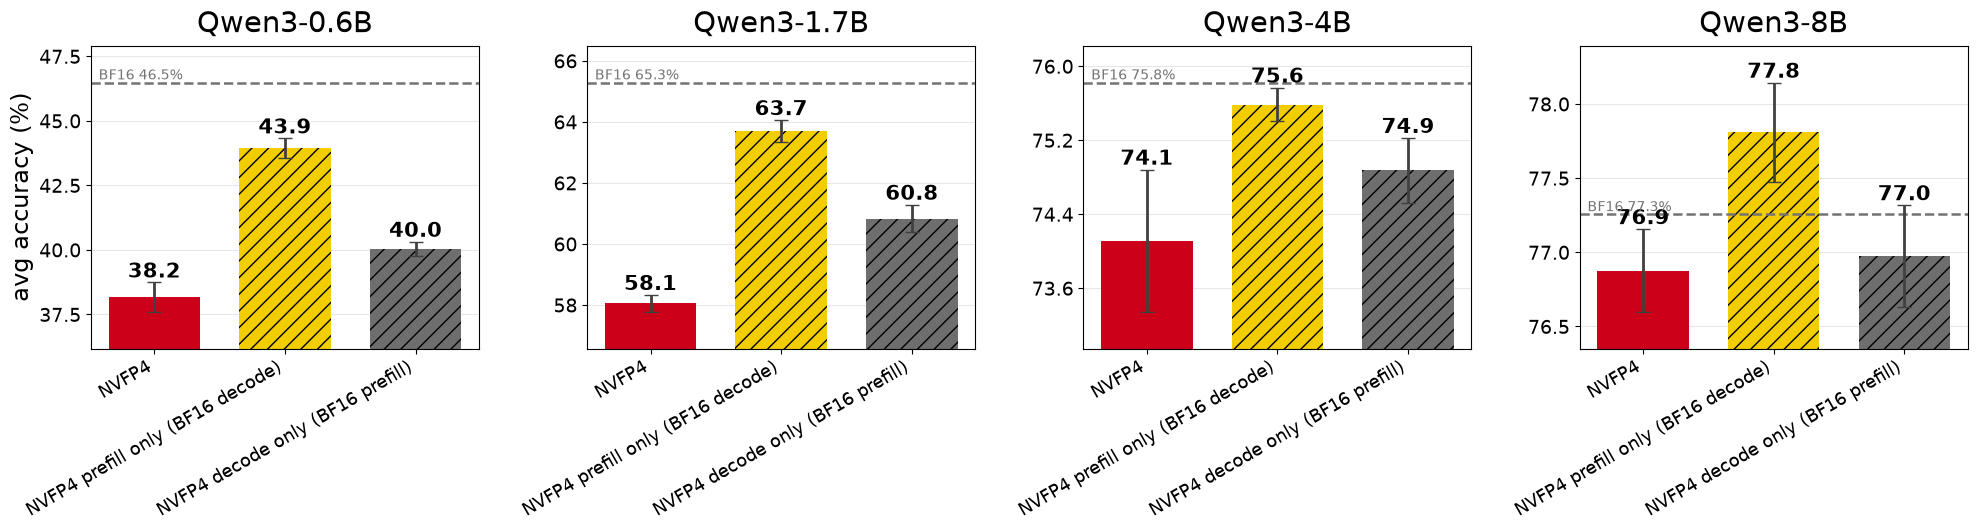

In [4]:
plot_recovery_bars(["nvfp4", "nvfp4prefill", "nvfp4decode"],
                   outfile="figures/bars_phase_isolation.pdf")


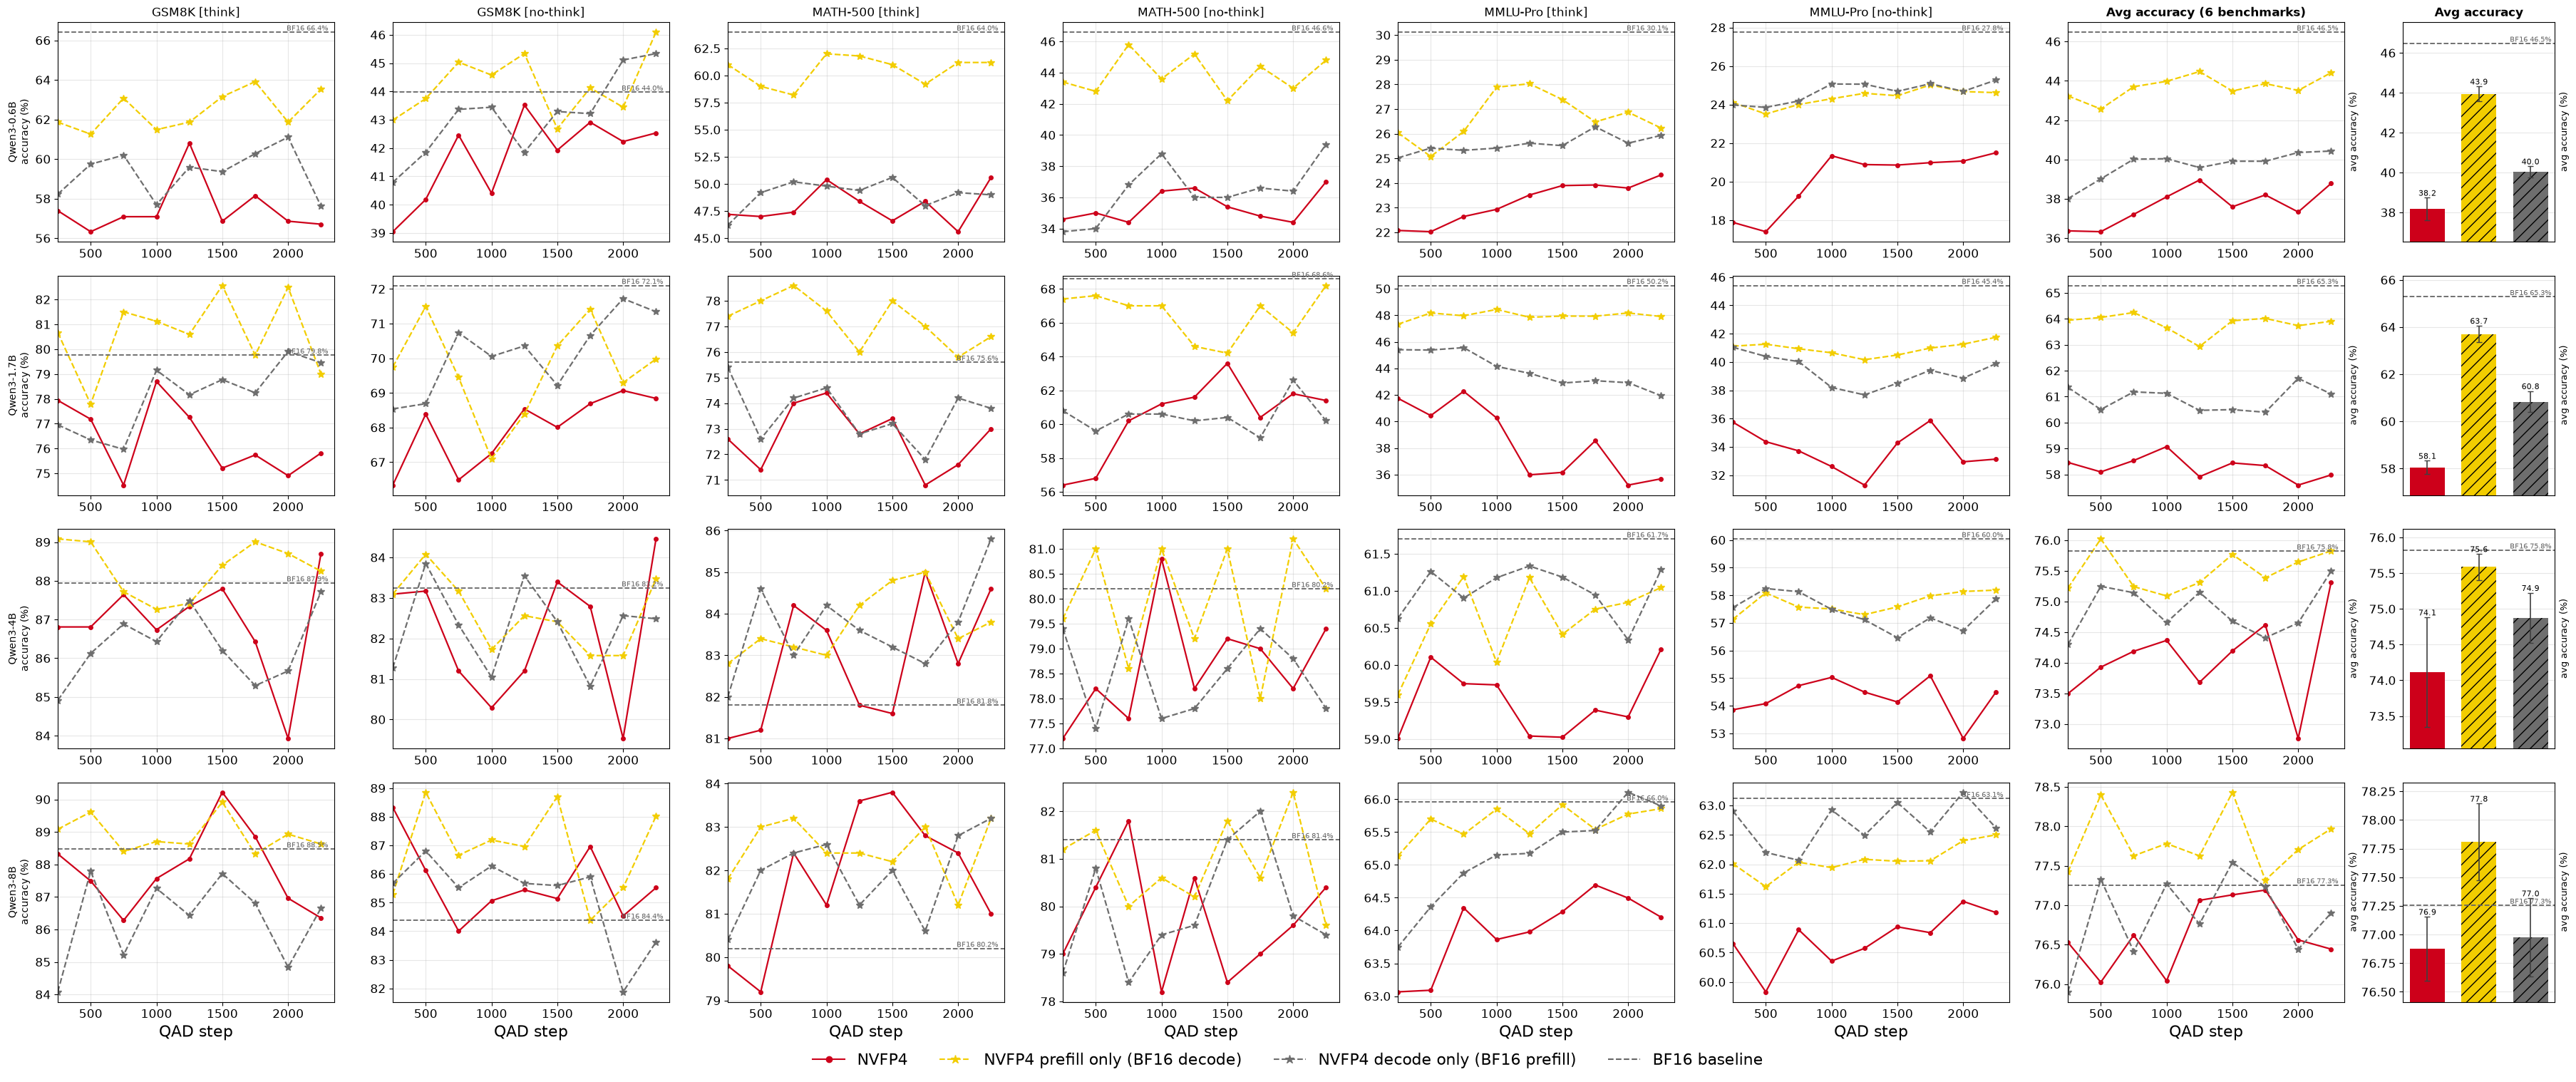

note: Qwen3-0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])


In [5]:
plot_grid(["nvfp4", "nvfp4prefill", "nvfp4decode"],
          "figures/qad_phase_isolation.pdf")

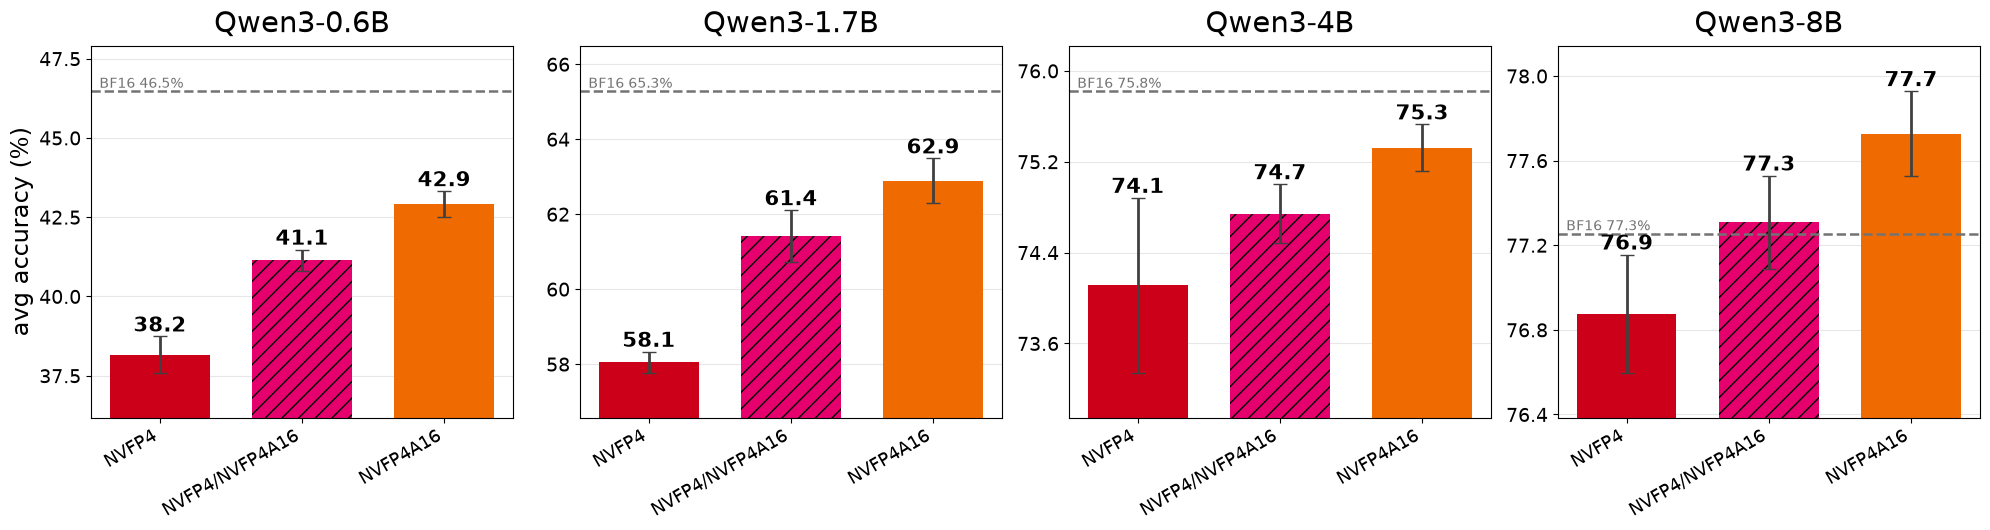

In [6]:
plot_recovery_bars(["nvfp4", "nvfp4pdshared", "nvfp4a16"],
                   outfile="figures/bars_nvfp4_activations.pdf")


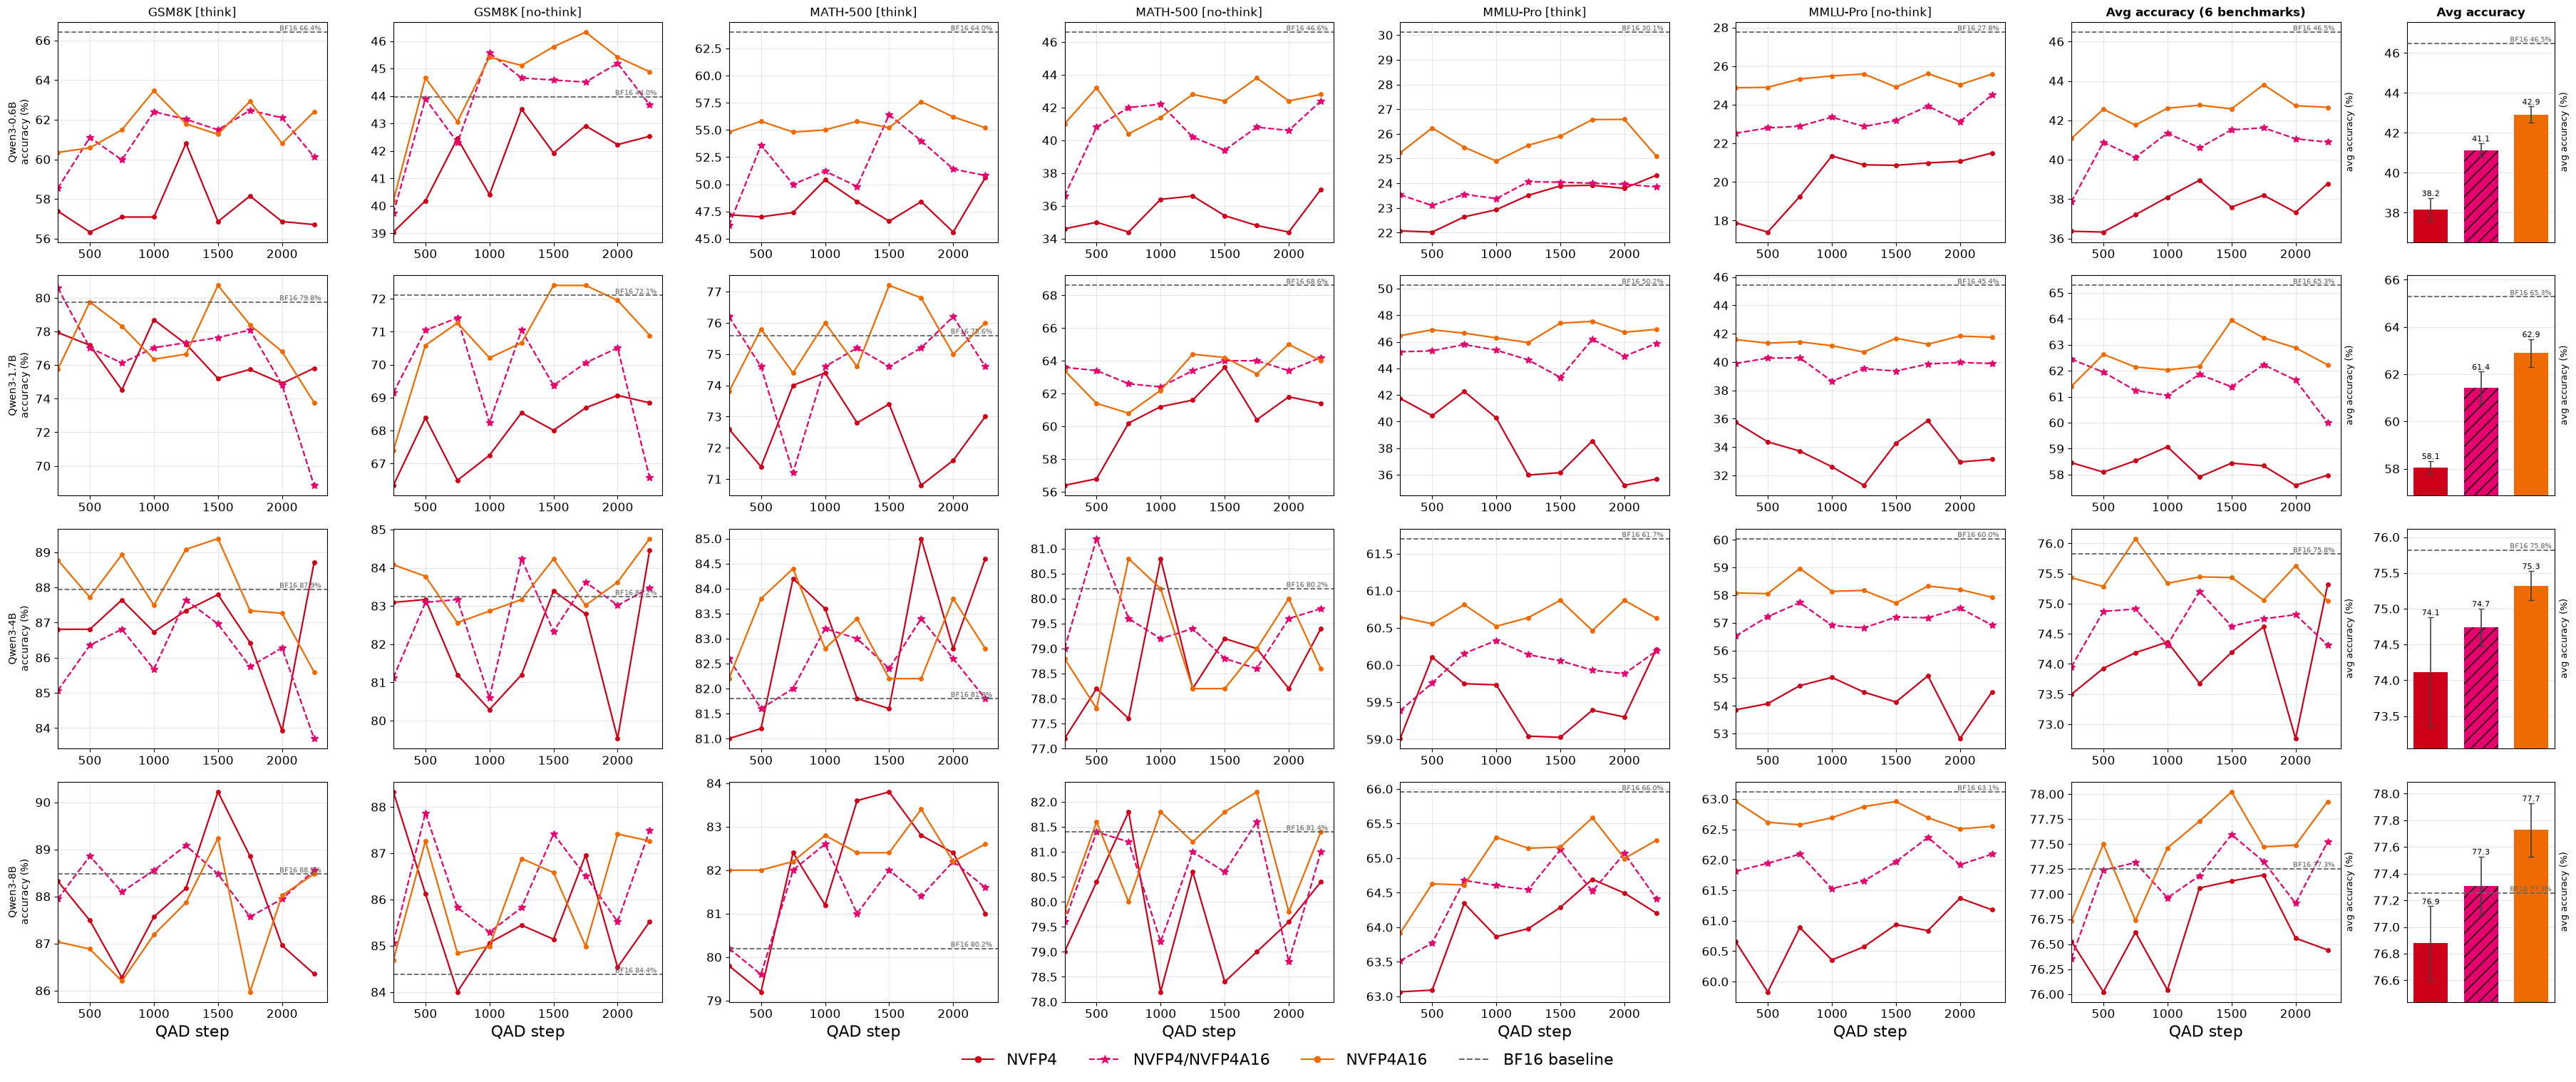

note: Qwen3-0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-0.6B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-1.7B NVFP4A16 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MA

In [7]:
plot_grid(["nvfp4", "nvfp4pdshared", "nvfp4a16"],
          "figures/nvfp4_activations.pdf")

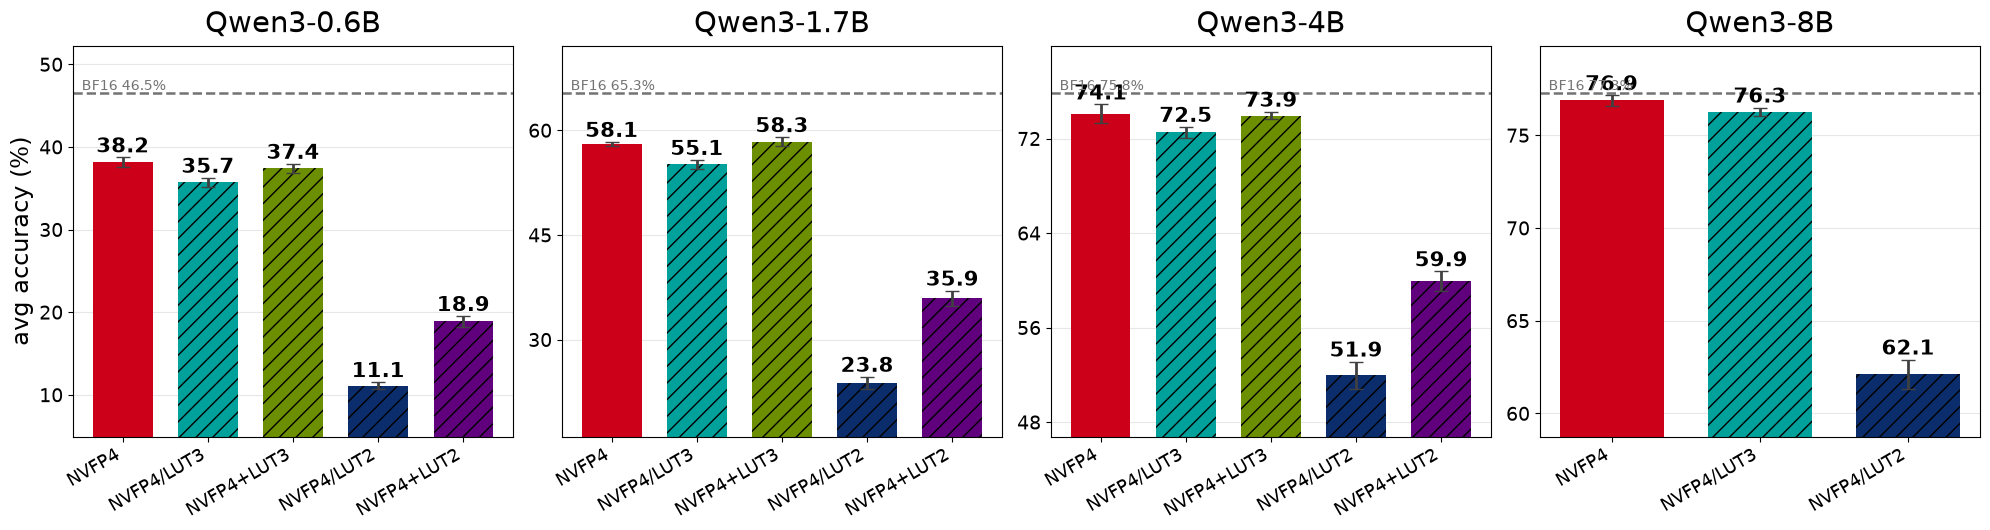

In [8]:
plot_recovery_bars([
        "nvfp4",
        "nvfp4lloyd43upcast", "nvfp4lloyd43split",
        "nvfp4lloyd21upcast", "nvfp4lloyd21split",
    ],
                   outfile="figures/bars_nvfp4_lloyd43_disagg.pdf")


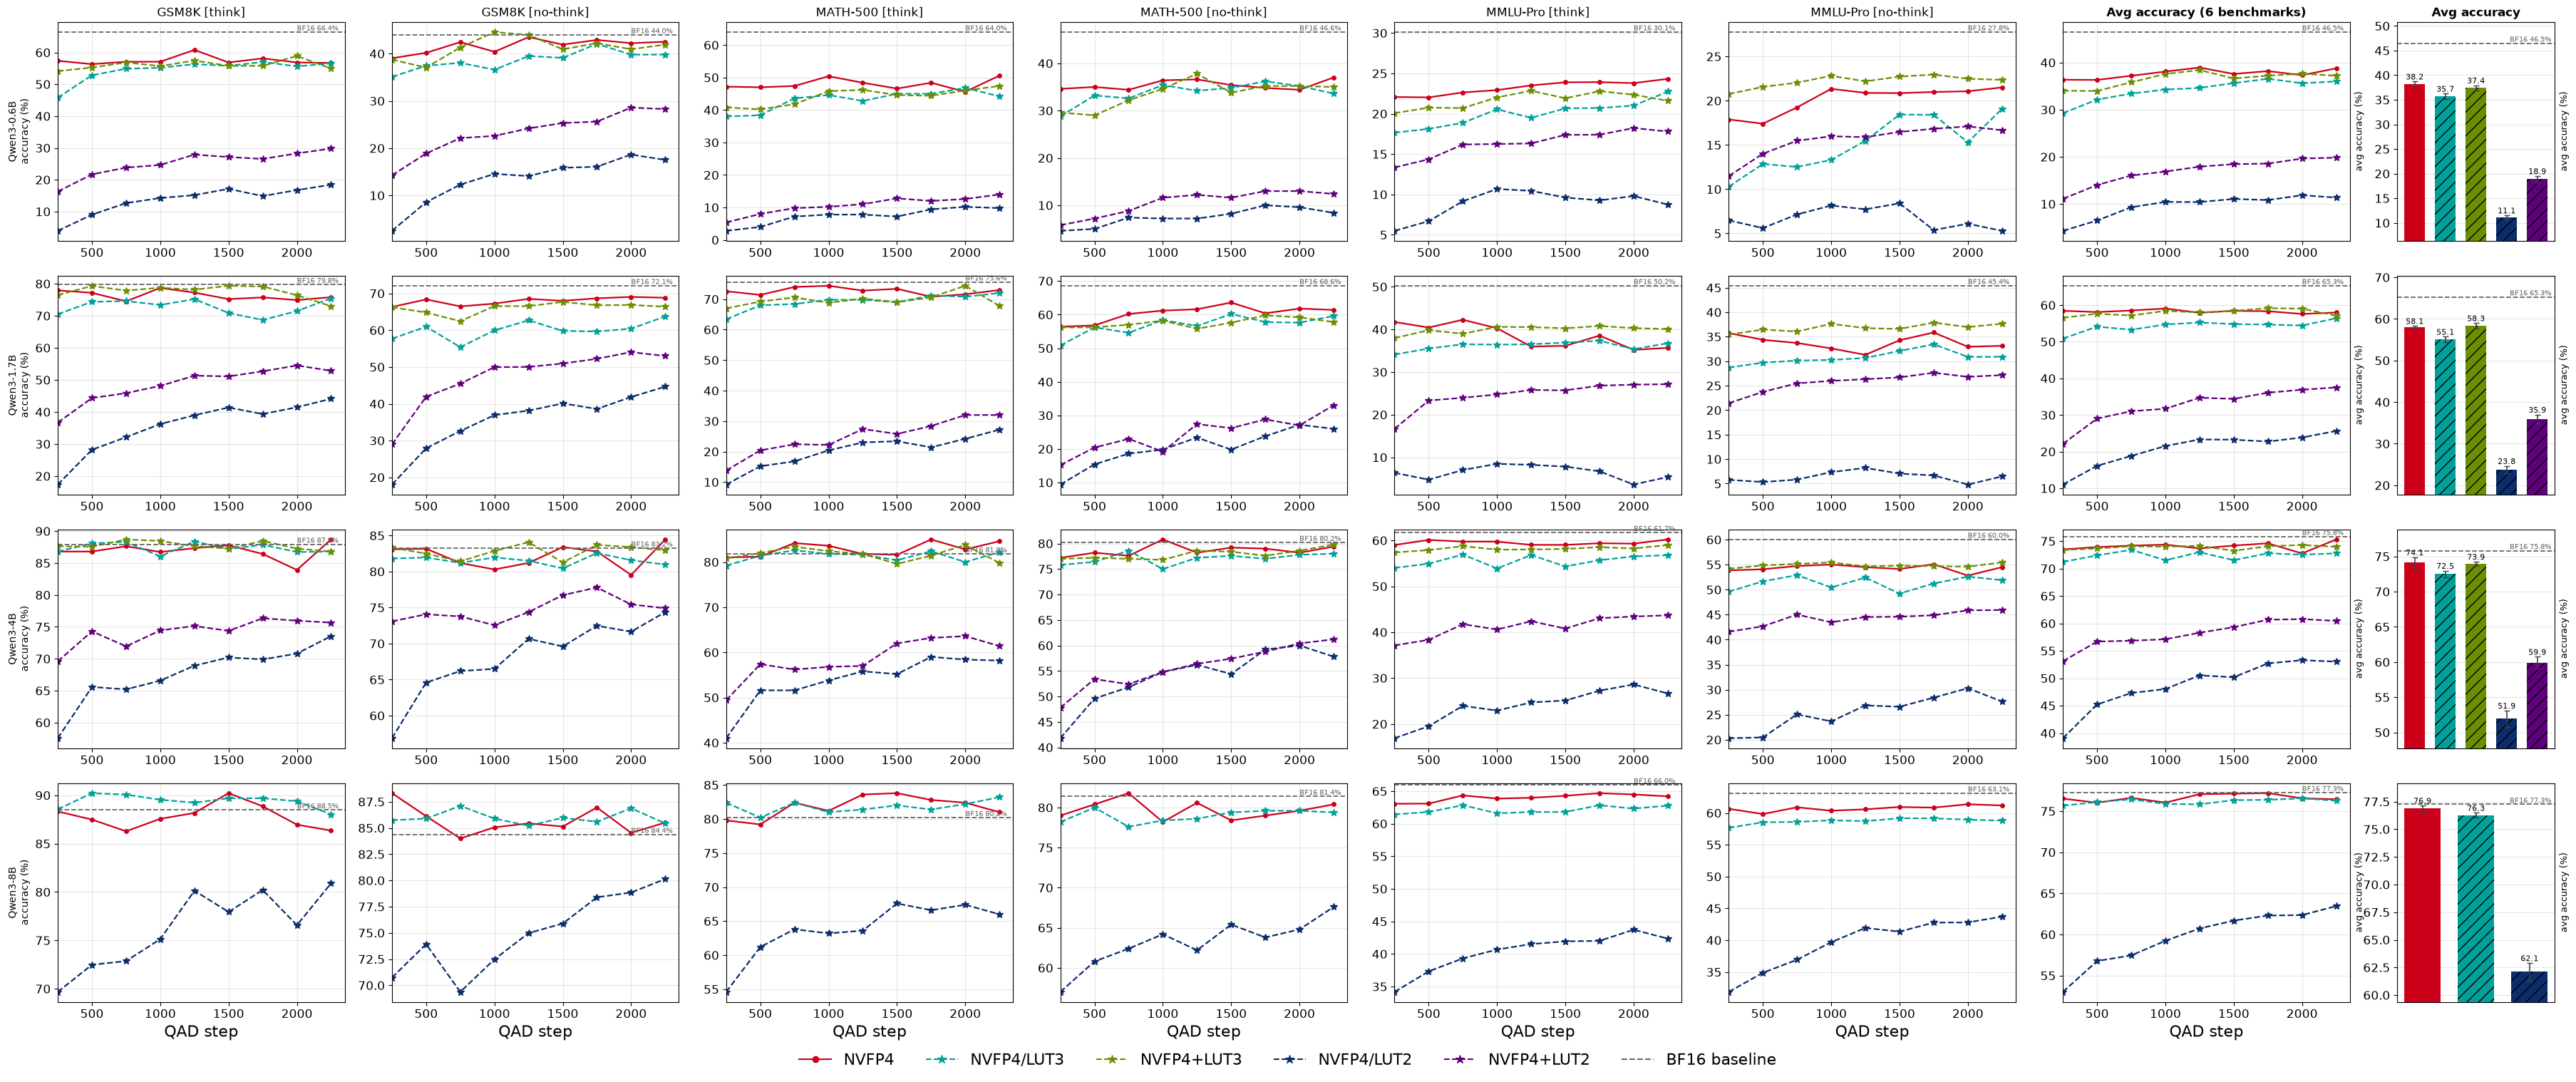

note: Qwen3-0.6B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-1.7B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])
note: Qwen3-4B NVFP4 — steps [100, 200, 300, 400, 600, 700] not averaged (missing one of ['GSM8K [think]', 'GSM8K [no-think]', 'MATH-500 [think]', 'MATH-500 [no-think]', 'MMLU-Pro [think]', 'MMLU-Pro [no-think]'])


In [9]:
plot_grid([
        "nvfp4",
        "nvfp4lloyd43upcast", "nvfp4lloyd43split",
        "nvfp4lloyd21upcast", "nvfp4lloyd21split",
    ],
          "figures/qad_nvfp4_lloyd43_disagg.pdf")

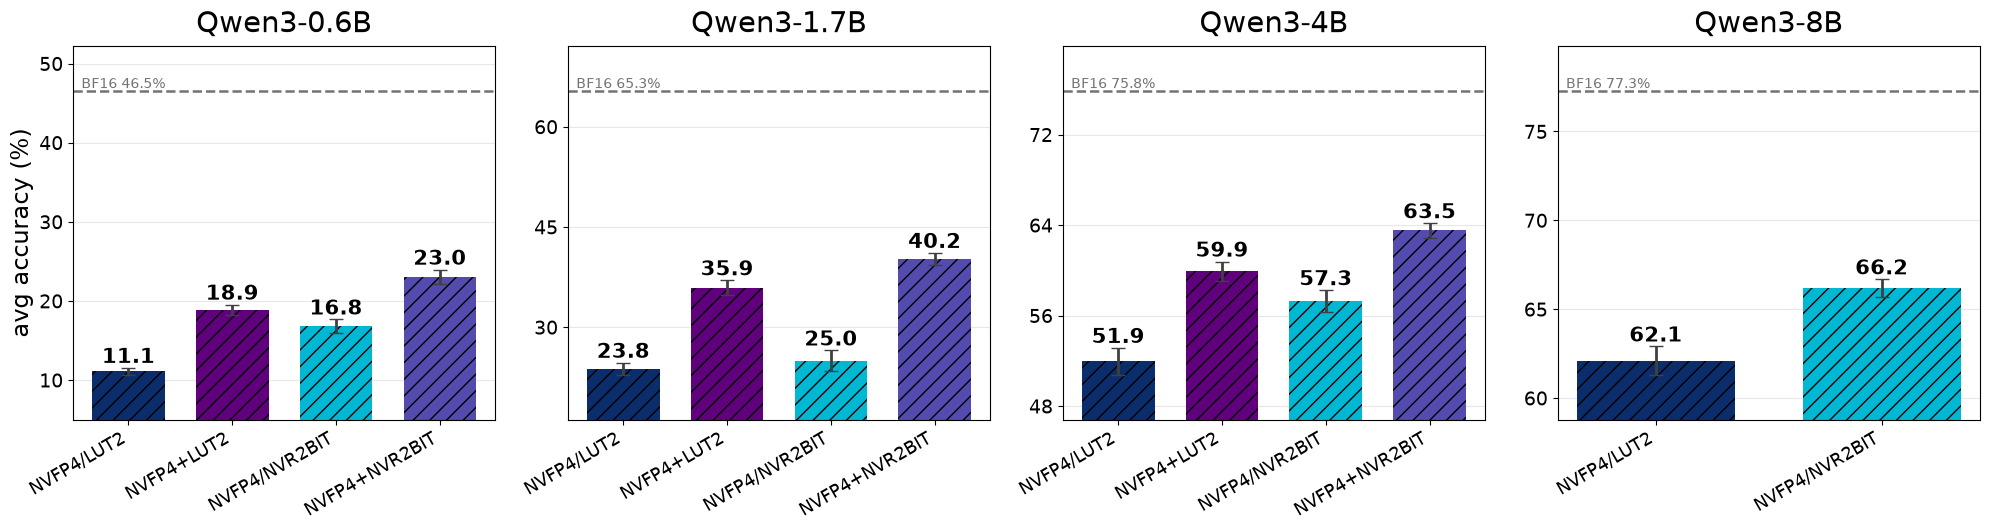

In [10]:
plot_recovery_bars(["nvfp4lloyd21upcast", "nvfp4lloyd21split", "nvfp4nvr2bitupcast", "nvfp4nvr2bitsplit"])


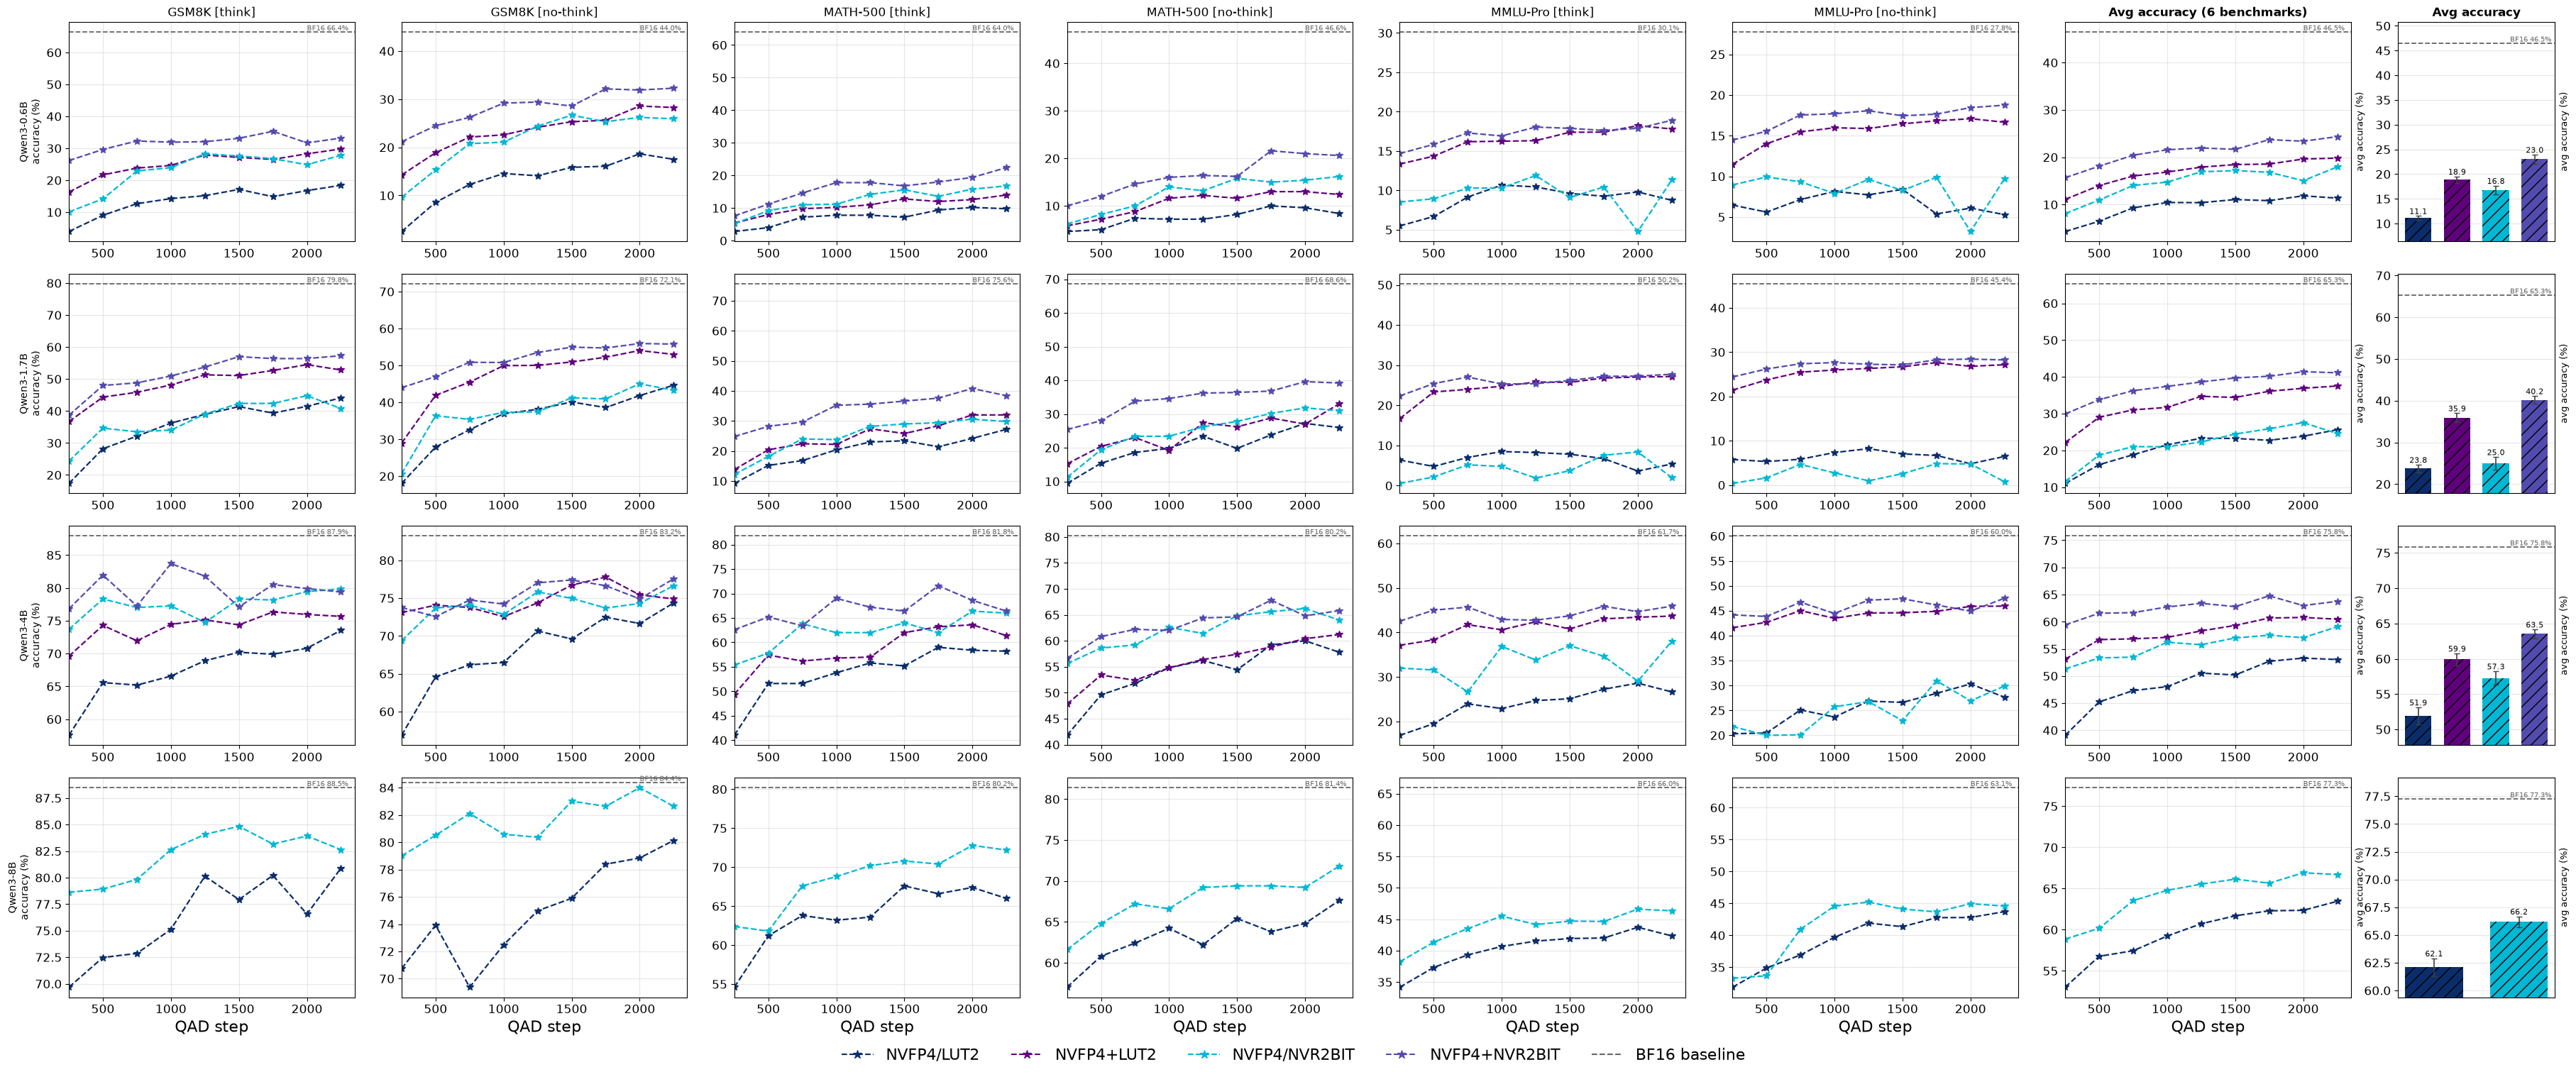

In [11]:
plot_grid(["nvfp4lloyd21upcast", "nvfp4lloyd21split", "nvfp4nvr2bitupcast", "nvfp4nvr2bitsplit"], "figures/whatever.pdf")

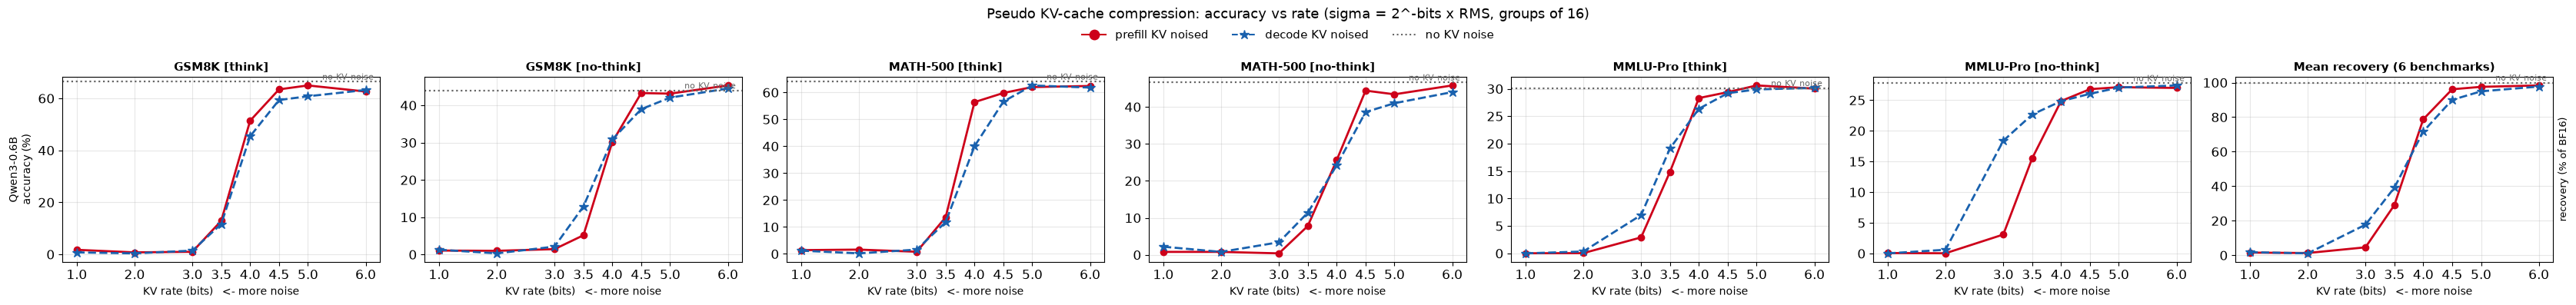

In [12]:
# KV-CACHE COMPRESSION SWEEP: accuracy vs rate, prefill-noise against decode-noise.
#
# Pseudo-compression (qad/kv_noise_connector.py): a token's K/V is degraded ONCE as it is
# written to the paged cache, by N(0, sigma^2) per contiguous group of 16 channels, with
#     sigma = 2^-kv_bits * RMS(group)
# so 4^-kv_bits of distortion POWER -- Shannon's D(R) for a Gaussian source. Lower bits =
# more noise. The right-hand end of each x axis is therefore the *gentle* end.
#
# Two arms, run on ONE BF16 checkpoint, so nothing here is confounded by training:
#   kvP  prefill engine noised, decode untouched  -> cost of compressing PROMPT KV
#   kvD  decode engine noised, prefill untouched  -> cost of compressing GENERATED KV
#
# READ THE ARMS WITH CARE. On these benchmarks prompts are long and generations short, so
# at equal rate the prefill arm degrades far MORE KV entries than the decode arm. A flat
# kvD curve therefore does not by itself show that decode KV is robust -- it may mean
# there was little of it to damage. The comparison is only fair per KV entry.
#
# Note also that the cache stores POST-RoPE keys (qwen3.py applies rotary_emb before
# self.attn writes the cache), so both arms perturb rotated keys -- which is what a real
# KV codec compresses.
import glob as _glob

KV_RE_PLOT = __import__("re").compile(
    r"Qwen3-([0-9.]+B)-unquantized-kv([pd])(\d+(?:\.\d+)?)$")
KV_ARMS = {"p": ("prefill KV noised", RED, "-", "o"),
           "d": ("decode KV noised", BLUE, "--", "*")}


def _load_kv_sweep():
    """{(model, arm, bits, task@mode): accuracy} straight from the results trees.

    Read separately from `models` because these runs are not checkpoints: one BF16 model
    at several rates, tagged ...-kvp<bits> / -kvd<bits>, with no quantizer or step.
    """
    out = {}
    for mode, tree in (("think", "results/disagg/think"),
                       ("nothink", "results/disagg/nothink")):
        for d in _glob.glob(f"../qad/{tree}/*-unquantized-kv*"):
            m = KV_RE_PLOT.search(d.rstrip("/").split("/")[-1])
            if not m:
                continue
            model, arm, bits = f"Qwen-Qwen3-{m.group(1)}", m.group(2), float(m.group(3))
            for f in _glob.glob(f"{d}/step_*.json"):
                try:
                    res = json.load(open(f)).get("results", {})
                except Exception:
                    continue
                for task, (_, key) in BENCHMARKS.items():
                    if task in res and key in res[task]:
                        out[(model, arm, bits, f"{task}@{mode}")] = 100.0 * res[task][key]
    return out


def plot_kv_sweep(outfile=None, scale=1.0):
    """One row per model; columns = benchmarks then mean recovery, x = kv_bits."""
    data = _load_kv_sweep()
    if not data:
        print("no KV-noise results on disk yet (looking for *-unquantized-kv[pd]<bits>)")
        return
    kv_models = sorted({k[0] for k in data}, key=_size)
    panels = tasks + [AVG]
    F = lambda pt: pt * scale
    fig, axes = plt.subplots(len(kv_models), len(panels),
                             figsize=(4.8 * len(panels) * scale, 3.7 * len(kv_models) * scale),
                             squeeze=False)
    for i, model in enumerate(kv_models):
        bl_all = baselines.get(model, {})
        for j, panel in enumerate(panels):
            ax = axes[i][j]
            for arm, (label, color, ls, mk) in KV_ARMS.items():
                bits = sorted({k[2] for k in data if k[0] == model and k[1] == arm})
                xs, ys = [], []
                for b in bits:
                    if panel == AVG:
                        # mean RECOVERY over the benchmarks, same definition as
                        # avg_recovery(): only rates where EVERY benchmark reported.
                        vals = [data.get((model, arm, b, t)) for t in tasks]
                        if any(v is None for v in vals) or not all(bl_all.get(t) for t in tasks):
                            continue
                        ys.append(sum(v / bl_all[t] for v, t in zip(vals, tasks))
                                  / len(tasks) * 100.0)
                    else:
                        v = data.get((model, arm, b, panel))
                        if v is None:
                            continue
                        ys.append(v)
                    xs.append(b)
                if xs:
                    ax.plot(xs, ys, marker=mk, markersize=F(9 if mk == "*" else 6),
                            linestyle=ls, linewidth=F(2.0), color=color, label=label)
            # uncompressed reference: 100% recovery by construction, or the raw baseline
            bl = 100.0 if panel == AVG else bl_all.get(panel)
            if bl is not None:
                ax.axhline(bl, ls=":", color="0.4", linewidth=F(1.6))
                ax.annotate("no KV noise", xy=(0.98, bl), xycoords=("axes fraction", "data"),
                            ha="right", va="bottom", fontsize=F(8), color="0.4")
            if i == 0:
                ax.set_title("Mean recovery (6 benchmarks)" if panel == AVG
                             else TASKS[panel][0], fontweight="bold", fontsize=F(11))
            if j == 0:
                ax.set_ylabel(model.replace("Qwen-", "") + "\naccuracy (%)", fontsize=F(10))
            if panel == AVG:
                ax.set_ylabel("recovery (% of BF16)", fontsize=F(9))
                ax.yaxis.set_label_position("right")
            if i == len(kv_models) - 1:
                ax.set_xlabel("KV rate (bits)   <- more noise", fontsize=F(10))
            ax.set_xticks(sorted({k[2] for k in data if k[0] == model}))
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
    handles = [plt.Line2D([], [], color=c, ls=ls, marker=mk, markersize=F(9), label=lab)
               for lab, c, ls, mk in KV_ARMS.values()]
    handles.append(plt.Line2D([], [], color="0.4", ls=":", label="no KV noise"))
    fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=F(11),
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Pseudo KV-cache compression: accuracy vs rate "
                 "(sigma = 2^-bits x RMS, groups of 16)", fontsize=F(13), y=1.06)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


plot_kv_sweep(outfile="figures/qad_kv_noise_sweep.pdf")


# Sweep progress & ETA

Reads SLURM plus the eval logs on disk and reports, per running job, **which stage of
the pipeline it is in** and how far through generation it is — then an ETA for the
whole sweep.

Stages come from markers the driver prints, so "no output" is never mistaken for
"stalled": lm-eval is silent for the whole generation phase, which is most of a job's
life. Progress inside that phase is read from the proxy's completed-request count
instead.

ETA uses the *observed* median runtime of already-COMPLETED jobs of the same kind
rather than a guess, and adds a queue-drain term for PENDING jobs based on how many can
run at once.


/tmp/ipykernel_1351279/15539577.py:142: UserWarning: You passed an edgecolor/edgecolors ('white') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([x], [acc], s=F(120), c=colour,


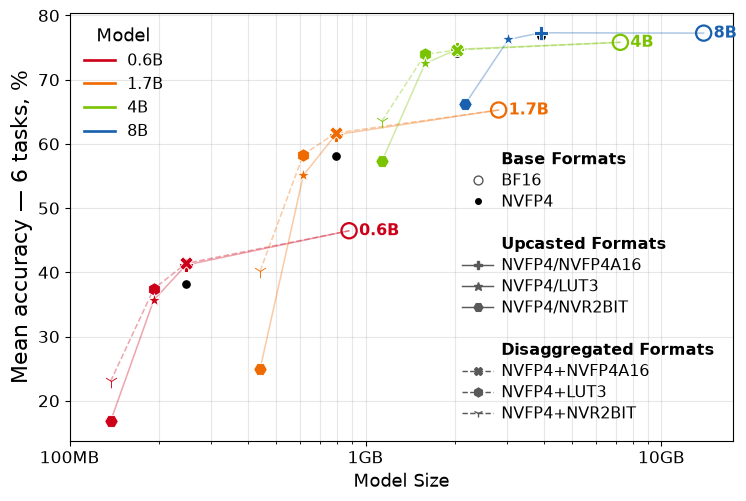

In [13]:
# PARETO: decode-side weight footprint vs accuracy.
#
# The question every one of these formats is really answering: for a given number of
# GIGABYTES you must hold resident to decode, how much accuracy do you get? Decode is the
# memory-bound phase, so its weight footprint is the deployment cost -- and a 2-bit 8B may
# beat a 4-bit 4B at the same size, which is invisible in any per-model figure.
#
# EXCLUDES embeddings and lm_head, which are not quantized by any of these formats (they
# would add a constant to every point and compress the interesting differences). Sizes are
# the DECODE half only; the prefill checkpoint is a separate residency question.
#
# HONESTY ABOUT THE X AXIS. This is the size a deployable kernel WOULD use, not the size on
# disk: the Lloyd/LUT formats ship pseudo-quantized (bf16 weights, no 2/3-bit kernel
# exists), so their bars are what such a kernel would cost, not what we measured. NVFP4
# numbers are real. Block scales are included at 8 bits per group of 16 (+0.5 bits/weight)
# because a deployed cache pays for them.
import numpy as _np

# Non-embedding linear parameters, from each config: L*(q+k+v+o) + L*3*i*h.
LINEAR_PARAMS = {"Qwen-Qwen3-0.6B": 0.440e9, "Qwen-Qwen3-1.7B": 1.409e9,
                 "Qwen-Qwen3-4B":   3.633e9, "Qwen-Qwen3-8B":   6.946e9}

# Bits per weight the DECODE half stores. The prefill half may differ -- that is the whole
# point of the disaggregated formats -- and is deliberately not counted here.
DECODE_BITS = {
    # Homogeneous NVFP4 is included as a REFERENCE, not a family member: it belongs to
    # neither chain, so it is drawn small and black and connected to nothing. It marks
    # "quantize everything to 4 bits and stop" -- the thing every dual format has to beat.
    "nvfp4": 4,
    "nvfp4pdshared": 4, "nvfp4pdsplit": 4,
    "nvfp4lloyd43upcast": 3, "nvfp4lloyd43split": 3,
    # "nvfp4lloyd21upcast": 2, "nvfp4lloyd21split": 2,
    "nvfp4nvr2bitupcast": 2, "nvfp4nvr2bitsplit": 2,
}
SCALE_BITS_PER_WEIGHT = 8 / 16       # one FP8 block scale per 16 weights


def decode_gb(model, method):
    bits = DECODE_BITS[method] + (SCALE_BITS_PER_WEIGHT if DECODE_BITS[method] < 16 else 0)
    return LINEAR_PARAMS[model] * bits / 8 / 1e9


def tail_accuracy(model, method, task_subset=None, models_src=None, baselines_src=None):
    """Mean RAW accuracy over the given tasks (defaults to all plotted tasks), last-5 steps.

    Raw accuracy, not recovery, because the y axis has to be comparable ACROSS models --
    recovery is normalised per model and would put every model's BF16 at 100%, hiding
    exactly the size/quality trade this figure exists to show.
    """
    _tasks = task_subset if task_subset is not None else tasks
    _msrc = models_src if models_src is not None else models
    vals = []
    for t in _tasks:
        curve = _msrc.get(model, {}).get(method, {}).get(t)
        if not curve:
            return None
        steps = [s for s in sorted(curve) if s >= MIN_STEP and s % 250 == 0][-TAIL_N:]
        if not steps:
            return None
        # NOT *100: the loader already stores accuracy in percent (baselines are
        # 66.4, not 0.664), and double-scaling put the quantized points at ~6000%
        # while the BF16 references collapsed onto the axis.
        vals.append(sum(curve[s] for s in steps) / len(steps))
    return sum(vals) / len(vals)


# Colour now identifies the MODEL and marker identifies the FORMAT, which is the pairing
# this figure needs: the question is whether a compressed big model beats an uncompressed
# small one, so the eye has to group by model first. That is the opposite of the per-model
# figures, where colour is the method -- deliberately, because there every panel IS one
# model and colour is free to carry the format.
MODEL_COLOUR = {"Qwen-Qwen3-0.6B": RED, "Qwen-Qwen3-1.7B": ORANGE,
                "Qwen-Qwen3-4B": GREEN, "Qwen-Qwen3-8B": BLUE}
# Distinct shapes, ordered so the families read together: circles = homogeneous,
# triangles/diamonds = duals, squares = LUT.
METHOD_MARKER = {
    "nvfp4": "o", "nvfp4a16": "s",
    "lloyd3bit": "D", "lloyd43": "^", "lloyd21": "v",
    "nvfp4pdshared": "P", "nvfp4pdsplit": "X",
    "nvfp4prefill": "<", "nvfp4decode": ">",
    "nvfp4lloyd43shared": "p", "nvfp4lloyd43split": "h", "nvfp4lloyd43upcast": "*",
    "nvfp4lloyd21upcast": "d", "nvfp4lloyd21split": "8",
    "nvfp4nvr2bitupcast": "H", "nvfp4nvr2bitsplit": "1",
}


# Two families, and the figure now draws one line per family per model rather than a
# single trace through both. They answer different questions and interpolating between
# them would imply a trade that does not exist:
#
#   SHARED/UPCAST  one master. The decode weight IS the storage, and prefill is derived
#                  from it (or shares it). Solid.
#   DISAGGREGATED  two masters that diverge, at 2x master/optimizer memory and 2x linear
#                  FLOPs. Dashed.
#
# Both chains include the model's BF16 point, so each line reads as "starting from
# uncompressed, here is what this family buys".
def _family(method):
    if method.endswith(("upcast", "shared")):
        return "upcast"
    if method.endswith("split"):
        return "disagg"
    return None


FAMILY_LS = {"upcast": "-", "disagg": "--"}
# Drawn in black at reduced size, outside both families and both colour keys.
REFERENCE = {"nvfp4"}


def plot_pareto(methods=None, outfile=None, scale=1.0, annotate_bf16=True,
               task_subset=None, models_src=None, baselines_src=None):
    """Pareto of decode memory vs accuracy.

    task_subset: list of task keys (e.g. ["minerva_math500@think"]) to use instead of
        the full `tasks` list. Defaults to all plotted tasks.
    """
    _tasks = task_subset if task_subset is not None else tasks
    _msrc = models_src if models_src is not None else models
    _bsrc = baselines_src if baselines_src is not None else baselines
    methods = [m for m in (methods or PLOT_METHODS) if m in found and m in DECODE_BITS]
    F = lambda pt: pt * scale
    fig, ax = plt.subplots(figsize=(9.5 * scale, 6.4 * scale))

    for model in MODEL_ORDER:
        if model not in LINEAR_PARAMS:
            continue
        colour = MODEL_COLOUR.get(model, "0.4")
        short = model.replace("Qwen-Qwen3-", "")
        chains = {"upcast": [], "disagg": []}
        for method in methods:
            acc = tail_accuracy(model, method, _tasks, models_src=_msrc)
            if acc is None:
                continue
            x = decode_gb(model, method)
            fam = _family(method)
            if fam:
                chains[fam].append((x, acc))
            if method in REFERENCE:
                ax.scatter([x], [acc], s=F(34), c="black", marker="o", zorder=3)
            else:
                ax.scatter([x], [acc], s=F(120), c=colour,
                           marker=METHOD_MARKER.get(method, "o"),
                           edgecolors="white", linewidths=F(0.8), zorder=3)
        bl = _bsrc.get(model, {})
        if annotate_bf16 and all(bl.get(t) for t in _tasks):
            xb = LINEAR_PARAMS[model] * 16 / 8 / 1e9
            yb = sum(bl[t] for t in _tasks) / len(_tasks)
            # BF16 anchors BOTH chains: it is the uncompressed origin of each family.
            for c in chains.values():
                c.append((xb, yb))
            ax.scatter([xb], [yb], s=F(150), facecolors="none", edgecolors=colour,
                       linewidths=F(2.0), zorder=4)
            ax.annotate(short, (xb, yb), textcoords="offset points",
                        xytext=(F(9), F(-4)), fontsize=F(14), fontweight="bold",
                        color=colour)
        for fam, chain in chains.items():
            if len(chain) > 1:
                chain.sort()
                ax.plot([c[0] for c in chain], [c[1] for c in chain], color=colour,
                        ls=FAMILY_LS[fam], lw=F(1.4), alpha=0.35, zorder=1)

    ax.set_xscale("log")
    # Explicit decade ticks in human units. matplotlib's default log labels here are
    # 10^0 / 10^1, which reads as "1" and "10" with no unit and hides that the left half
    # of the figure is in the hundreds of MB.
    ax.set_xticks([0.1, 1.0, 10.0])
    ax.set_xticklabels(["100MB", "1GB", "10GB"])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel("Model Size", fontsize=F(16))
    task_label = (BENCHMARKS[_tasks[0].split("@")[0]][0]
                  if len(_tasks) == 1 else f"{len(_tasks)} tasks")
    ax.set_ylabel(f"Mean accuracy — {task_label}, %", fontsize=F(20))
    ax.grid(True, which="both", alpha=0.3)
    ax.set_axisbelow(True)

    # ONE format legend, with the group names as inert rows inside it. Three stacked
    # legends each own their own text column, so the labels never line up with each
    # other; a single legend has one handle column and one text column, which is what
    # makes the entries align horizontally. The group headers are handles with no marker
    # and no line -- they occupy the handle column invisibly and read as section titles.
    def _handle(q):
        if q is None:
            return plt.Line2D([], [], color="0.35", ls="none", marker="o",
                              markerfacecolor="none", markersize=F(8), label="BF16")
        if q in REFERENCE:
            return plt.Line2D([], [], color="black", ls="none", marker="o",
                              markersize=F(5), label=METHODS[q][0])
        return plt.Line2D([], [], color="0.35", ls=FAMILY_LS.get(_family(q), "none"),
                          lw=F(1.3), marker=METHOD_MARKER.get(q, "o"),
                          markersize=F(8), label=METHODS[q][0])

    def _header(text):
        return plt.Line2D([], [], ls="none", marker="none", label=text)

    groups = [
        ("Base Formats",          [None] + [m for m in methods if m in REFERENCE]),
        ("Upcasted Formats",      [m for m in methods if _family(m) == "upcast"]),
        ("Disaggregated Formats", [m for m in methods if _family(m) == "disagg"]),
    ]
    handles = []
    for i, (title, qs) in enumerate(groups):
        if not qs:
            continue
        if i:
            handles.append(_header(" "))        # blank row between sections
        handles.append(_header(title))
        handles += [_handle(q) for q in qs]
    leg = ax.legend(handles=handles, fontsize=F(14), frameon=False, loc="lower right",
                    labelspacing=0.35, handletextpad=0.5, borderaxespad=0.8)
    # Bold the section titles so they read as headers rather than unmarked entries.
    titles = {t for t, _ in groups}
    for txt in leg.get_texts():
        if txt.get_text() in titles:
            txt.set_fontweight("bold")
    ax.add_artist(leg)

    colour_handles = [plt.Line2D([], [], color=MODEL_COLOUR[m], ls="-", lw=F(2.4),
                                 label=m.replace("Qwen-Qwen3-", ""))
                      for m in MODEL_ORDER if m in MODEL_COLOUR]
    ax.legend(handles=colour_handles, fontsize=F(14), frameon=False,
              loc="upper left", title="Model", title_fontsize=F(16))

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight", transparent=True)
    plt.show()


plot_pareto(scale=0.8, outfile="figures/qad_pareto_decode_size.pdf")


In [15]:
import json, os, re, subprocess, glob, time
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path("..")
LOGS = ROOT / "logs" / "eval_disagg"
JOB_NAME = "qad-disagg"

def sh(cmd):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=60).stdout
    except Exception:
        return ""

def to_min(t):
    """SLURM elapsed (D-HH:MM:SS / HH:MM:SS / MM:SS) -> minutes."""
    if not t or t in ("0:00",): return 0.0
    d, _, rest = t.partition("-")
    if not rest: rest, d = d, "0"
    p = [float(x) for x in rest.split(":")]
    sec = p[-1] + (p[-2] * 60 if len(p) > 1 else 0) + (p[-3] * 3600 if len(p) > 2 else 0)
    return (float(d) * 86400 + sec) / 60

# quantizer slug -> the label used everywhere else (plots, sweep --formats)
QUANT_LABEL = {
    "unquantized": "BF16", "nvfp4a16": "NVFP4A16", "nvfp4pdshared": "NVFP4-pd-shared",
    "nvfp4pdsplit": "NVFP4-pd-split", "lloyd3bit": "W3A16-Lloyd", "nvfp4": "NVFP4",
}
# longest slug first: "nvfp4" is a prefix of "nvfp4a16" and both pd variants
_SLUGS = sorted(QUANT_LABEL, key=len, reverse=True)

# Pseudo KV-cache compression runs (kv_noise_connector.py) tag themselves
# ...-kvp<bits> / ...-kvd<bits>: the rate applied to the PREFILL or the DECODE engine's
# KV cache, where sigma = 2^-bits * RMS(group of 16), i.e. 4^-bits of distortion power.
# The rate is NOT in the driver banner, only in the tag, so it has to be carried
# separately or enrich() below silently relabels every arm as plain "BF16" and the whole
# sweep looks like one repeated baseline.
# \d+(?:\.\d+)? -- fractional rates (3.5, 4.5) are swept too.
KV_RE = re.compile(r"-kv([pd])(\d+(?:\.\d+)?)(?:[-/_]|$)")

def parse_kv(text):
    """'P4' / 'D2' for a KV-noise arm, else '' -- prefill or decode, at that bit rate."""
    m = KV_RE.search(text or "")
    return f"{m.group(1).upper()}{m.group(2)}" if m else ""

def parse_tag(text):
    """(model size, format label) from a log-dir label or a results-tree tag.

    The KV rate is folded INTO the label so the aggregate tables, which key on
    (size, format), keep the arms apart instead of summing them into one row.
    """
    m = re.search(r"Qwen3-([0-9.]+B)", text or "")
    size = m.group(1) if m else "?"
    kv = parse_kv(text)
    suffix = f"+kv{kv}" if kv else ""
    for slug in _SLUGS:
        if re.search(rf"[-/]{slug}([-/_]|$)", text or ""):
            return size, QUANT_LABEL[slug] + suffix
    return size, ("?" + suffix if suffix else "?")

# ---- 1. what SLURM thinks. StdOut is included because it resolves size/format for
#         PENDING jobs too, which have not written a log line yet ------------------
rows = []
# -r expands array elements. Without it SLURM collapses pending ones into ranges
# ("479272_[3-9]" is ONE line), so a 204-element sweep reports ~30 pending and the
# ETA below comes out ~6x short.
#
# ArrayJobID/ArrayTaskID, NOT JobID: for an array element JobID is a distinct id
# (array 479274 task 2 -> JobID 479313) while the .out file is named 479274_2.out.
# Keying on JobID silently matched nothing, so 33 generating jobs displayed as
# "queued/starting". JobID is still read -- older stack dirs are named after it.
_W = [12, 10, 12, 14, 14, 250]
def _split(line):
    out, pos = [], 0
    for w in _W:
        out.append(line[pos:pos + w].strip()); pos += w
    return out

rows = []
for line in sh(f'squeue -u $(whoami) -h -r -n {JOB_NAME} '
               f'-O "ArrayJobID:12,ArrayTaskID:10,JobID:12,State:14,TimeUsed:14,StdOut:250"').splitlines():
    if not line.strip(): continue
    ajid, atid, jobid, state, elapsed, stdout = _split(line)
    jid = f"{ajid}_{atid}" if atid and atid != "N/A" else ajid
    size, fmt = parse_tag(os.path.basename(os.path.dirname(stdout)))
    rows.append({"id": jid, "array": ajid, "taskid": (atid if atid != "N/A" else "0"),
                 "jobid": jobid, "state": state, "elapsed": elapsed, "size": size, "fmt": fmt,
                 "kv": parse_kv(os.path.basename(os.path.dirname(stdout))),
                 "mode": "?", "step": "?", "task": "?", "tasks_raw": ""})

# ---- 2. stage + exact config of each job, from its own log -----------------------
# ordered most-advanced first; the first marker found wins
STAGES = [
    ("results ->",     "done (writing)"),
    ("lm_eval: tasks", "generating"),
    ("thinking",       "engines up"),
    ("stack ready",    "stack ready"),
    ("starting stack", "engines loading"),
    ("disagg-eval]",   "container up"),
]
log_index = {}
for f in glob.glob(str(LOGS / "*" / "*.out")):
    m = re.match(r"^(\d+)_(\d+)\.out$", os.path.basename(f))
    if m:
        jid = f"{m.group(1)}_{m.group(2)}" if m.group(2) != "4294967294" else m.group(1)
        log_index.setdefault(jid, f)

BANNER = re.compile(r"\[disagg-eval\] model=(\S+?)\s+(?:quantizer=(\S+)\s+iter=(\S+)\s+|UNQUANTIZED \(BF16\)\s+)"
                    r"think=(\d)\s+tasks=(.+)")

def enrich(r):
    """Fill stage/mode/step/task from the driver banner -- authoritative, unlike the dir name."""
    f = log_index.get(r["id"])
    if not f:
        r["stage"] = "queued/starting"; return r
    try: txt = open(f, errors="ignore").read()
    except OSError:
        r["stage"] = "?"; return r
    if (m := BANNER.search(txt)):
        model, quant, it, think, tasks = m.groups()
        r["size"], _ = parse_tag(model)
        # The banner is authoritative for size/format but knows nothing about the KV
        # rate, so re-attach it from the log-dir name; otherwise every kvp/kvd arm is
        # relabelled "BF16" here and 40 distinct runs collapse into one row.
        r["fmt"] = (QUANT_LABEL.get(quant, quant) if quant else "BF16") + (
            f"+kv{r['kv']}" if r.get("kv") else "")
        r["step"] = it or "0"
        r["mode"] = "think" if think == "1" else "nothink"
        r["tasks_raw"] = tasks.strip()
        r["task"] = r["tasks_raw"].replace("mmlu_flan_cot_zeroshot", "mmlu_cot")
    r["stage"] = next((name for marker, name in STAGES if marker in txt), "container up")
    return r

rows = [enrich(r) for r in rows]
running = [r for r in rows if r["state"] == "RUNNING"]
pending = [r for r in rows if r["state"] != "RUNNING"]

# ---- 3. live generation progress, from the proxy's completed-request count --------
# lm-eval prints NOTHING between "tasks" and its final score, so the per-job median is
# the only ETA available without this: a job 90% done and one 10% done look identical.
# The proxy logs one "prefill ok" per request, which is the one live counter there is.
#
# It measures the PREFILL side, which runs ahead of decode by up to the in-flight window
# (~512 at the current concurrency). So it is a slight over-estimate -- worst case ~4% on
# mmlu_pro -- and it saturates at 100% while the last decodes drain. Treat it as a
# leading indicator, not a completion signal.
TASK_DOCS = {"gsm8k": 1319, "minerva_math500": 500, "aime25": 30,
             "mmlu_pro": 12032, "mmlu_flan_cot_zeroshot": 1531}

def expected_docs(tasks_raw):
    n = sum(TASK_DOCS.get(t, 0) for t in (tasks_raw or "").split())
    return n or None

def proxy_done(r):
    """Requests prefilled so far, or None if this job has no proxy log yet.

    Two namings are tried: the stack dir is now keyed on ARRAY_JOB_ID so it matches
    the .out basename, but jobs launched before that fix are keyed on the element id.
    """
    for base in (r["array"], r["jobid"]):
        try:
            with open(LOGS / f"stack_{base}_{r['taskid']}" / "proxy.log", errors="ignore") as fh:
                return sum(1 for ln in fh if "prefill ok" in ln)
        except OSError:
            continue
    return None

def lmeval_progress(jid):
    """(done, total, timeouts) from lm-eval's own tqdm bar on stderr.

    Strictly better than counting proxy lines: tqdm counts DOCUMENTS, while the proxy
    counts REQUESTS, and a retried request is a second request for the same document.
    With timeouts running at 20-35% that gap is what pushed the bar past 100%.
    """
    f = log_index.get(jid)
    if not f: return None, None, 0
    try:
        with open(f[:-4] + ".err", "rb") as fh:              # tail only; these get large
            fh.seek(0, 2); fh.seek(max(0, fh.tell() - 262144))
            txt = fh.read().decode("utf-8", "replace")
    except OSError:
        return None, None, 0
    # Anchor on the "Requesting API" bar. lm-eval runs a preprocessing tqdm FIRST that
    # completes in seconds, so an unanchored N/M match reads that one and reports a job
    # 8 minutes in as 100% done -- with the bar hitting the top before generation starts.
    m = re.findall(r"Requesting API.*?(\d+)/(\d+) \[", txt.replace("\r", "\n"))
    done, total = (int(m[-1][0]), int(m[-1][1])) if m else (None, None)
    return done, total, txt.count("TimeoutError")

def bar(frac, width=14):
    filled = int(round(min(max(frac, 0.0), 1.0) * width))
    return "[" + "#" * filled + "-" * (width - filled) + "]"

for r in rows:
    if r["state"] != "RUNNING":
        r["done"] = r["total"] = r["frac"] = None; r["timeouts"] = 0
        continue
    done, total, r["timeouts"] = lmeval_progress(r["id"])
    if done is None:                        # no tqdm line yet -> fall back to the proxy
        done, total = proxy_done(r), expected_docs(r["tasks_raw"])
    r["done"], r["total"] = done, total
    r["frac"] = (done / total) if (done and total) else None

# ---- 3. ETA from OBSERVED runtimes of finished jobs ------------------------------
done_min = []
for line in sh('sacct -S now-12hours -u $(whoami) -n --format=JobID,JobName,State,Elapsed -P').splitlines():
    f = line.split("|")
    if len(f) == 4 and JOB_NAME in f[1] and f[2] == "COMPLETED" and re.match(r"^\d+(_\d+)?$", f[0]):
        done_min.append(to_min(f[3]))
done_min.sort()
median = done_min[len(done_min) // 2] if done_min else None

print("jobs: " + (", ".join(f"{k}={v}" for k, v in sorted(Counter(r["state"] for r in rows).items())) or "none queued"))
if median:
    print(f"observed median job runtime: {median:.0f} min  (n={len(done_min)} completed in last 12h)")
else:
    print("no completed jobs yet — ETA unavailable until the first one finishes")

# ---- 4. queue broken down by model size and format -------------------------------
if rows:
    q = defaultdict(lambda: [0, 0])
    for r in rows: q[(r["size"], r["fmt"])][0 if r["state"] == "RUNNING" else 1] += 1
    print(f"\nqueue by model / format:\n  {'size':6} {'format':19} {'run':>4} {'pend':>5}")
    for (size, fmt), (nr, np_) in sorted(q.items()):
        print(f"  {size:6} {fmt:19} {nr:4d} {np_:5d}")

# ---- 5. results already on disk, by size / format / thinking mode ----------------
disk = defaultdict(Counter)
for f in glob.glob(str(ROOT / "qad" / "results" / "disagg" / "*" / "*" / "step_*.json")):
    tree = Path(f).parts[-3]
    size, fmt = parse_tag(Path(f).parts[-2])
    disk[(size, fmt)]["think" if tree.endswith("_think") else "nothink"] += 1
if disk:
    print(f"\nresults on disk:\n  {'size':6} {'format':19} {'think':>6} {'nothink':>8}")
    for (size, fmt), c in sorted(disk.items()):
        print(f"  {size:6} {fmt:19} {c['think']:6d} {c['nothink']:8d}")
    print(f"  {'':6} {'TOTAL':17} {sum(c['think'] for c in disk.values()):6d} "
          f"{sum(c['nothink'] for c in disk.values()):8d}")
else:
    print("\nresults on disk: none yet")

# ---- 6. the running jobs themselves ----------------------------------------------
if running:
    print("\nstage tally:", dict(Counter(r["stage"] for r in running)))

    # ETA is computed per job BEFORE sorting, so it lives on the row and can be sorted
    # or inspected. The rate comes from the job's own elapsed time, hence the need for a
    # real sample first; "*" marks the median-based guess used until then.
    # Extrapolating from a job that has barely started is worthless: 1 doc of 12032 at
    # 3 min projects to ~42000 min. Below this much progress, fall back to the median.
    MIN_FRAC = 0.05
    for r in running:
        el = to_min(r["elapsed"])
        if r["frac"] and r["frac"] >= MIN_FRAC and el > 2:
            r["eta_min"], r["eta_src"] = max(0.0, (r["total"] - r["done"]) / (r["done"] / el)), ""
        else:
            r["eta_min"], r["eta_src"] = (max(0, median - el) if median else None), "*"

    # Sort by REAL progress, most complete first, so the jobs about to free a GPU are at
    # the top. Anything not yet generating has frac None and sinks to the bottom as a
    # block rather than being interleaved by elapsed time -- a job 2 min into loading
    # engines otherwise sorts above one 90% through generating.
    order = sorted(running, reverse=True,
                   key=lambda x: (x["frac"] is not None, x["frac"] or 0.0, to_min(x["elapsed"])))

    print(f"\nrunning jobs ({len(running)}):\n  {'id':>12}  {'size':5} {'format':19} {'mode':8} "
          f"{'step':>6} {'task':10} {'stage':16} {'elapsed':>8}  {'progress':16} {'eta':>7} {'t/o':>6}")
    for r in order[:25]:
        eta = f"~{r['eta_min']:.0f}m{r['eta_src']}" if r["eta_min"] is not None else "?"
        prog = f"{bar(r['frac'])} {r['frac'] * 100:3.0f}%" if r["frac"] is not None else (
               f"{r['done']} reqs" if r["done"] else "—")
        print(f"  {r['id']:>12}  {r['size']:5} {r['fmt']:17} {r['mode']:8} {r['step']:>6} "
              f"{r['task'][:10]:10} {r['stage']:16} {to_min(r['elapsed']):7.1f}m  {prog:16} "
              f"{eta:>7} {(r['timeouts'] or ''):>6}")
    if len(running) > 25:
        n_gen = sum(1 for r in order[25:] if r["frac"] is not None)
        print(f"  ... {len(running) - 25} more ({n_gen} generating, {len(running) - 25 - n_gen} not yet)")
    print("  progress = lm-eval's own doc counter; * = median-based ETA (no sample yet)")
    to = sum(r["timeouts"] or 0 for r in running)
    if to:
        print(f"  t/o = client TimeoutErrors ({to} across running jobs). Each one discards a "
              f"finished generation and resends it.")

# ---- 7. sweep ETA ----------------------------------------------------------------
# Prefer the CURRENT sweep's own pace over the sacct median. The median covers the last
# 12h, so right after switching benchmarks it describes the previous one -- it read
# 25 min while these mmlu_pro jobs were each projecting 150+. Live projections come
# from jobs actually running now, so they track the benchmark in flight.
projected = sorted(to_min(r["elapsed"]) / r["frac"]
                   for r in running if r["frac"] and r["frac"] >= 0.05)
job_min = projected[len(projected) // 2] if projected else median
src_lbl = f"live, n={len(projected)} running" if projected else f"sacct median, n={len(done_min)}"

if job_min and rows:
    conc = max(len(running), 1)
    waves = (len(pending) + conc - 1) // conc
    longest_running = max((job_min - to_min(r["elapsed"]) for r in running), default=0)
    eta_total = max(0, longest_running) + waves * job_min
    print(f"\ntypical job: {job_min:.0f} min  ({src_lbl})")
    print(f"sweep ETA: ~{eta_total:.01f} min "
          f"({len(running)} running, {len(pending)} pending, ~{conc} at a time, {waves} more wave(s))")
    # include the weekday: these sweeps routinely run past midnight, and a bare
    # "13:22" on a 28-hour ETA reads as a time that has already passed
    print(f"           finishing around "
          f"{time.strftime('%a %H:%M', time.localtime(time.time() + eta_total * 60))}"
          f"  ({eta_total / 60:.1f} h)")


jobs: PENDING=4, RUNNING=4
observed median job runtime: 25 min  (n=84 completed in last 12h)

queue by model / format:
  size   format               run  pend
  8B     ?                      0     2
  8B     NVFP4                  1     1
  8B     NVFP4-pd-shared        1     1
  8B     nvfp4lloyd43upcast     1     0
  8B     nvfp4nvr2bitupcast     1     0

results on disk:
  size   format               think  nothink
  0.6B   ?                      122      122
  0.6B   BF16                     2        1
  0.6B   BF16+kvD1                1        1
  0.6B   BF16+kvD2                1        1
  0.6B   BF16+kvD3                1        1
  0.6B   BF16+kvD3.5              1        1
  0.6B   BF16+kvD4                1        1
  0.6B   BF16+kvD4.5              1        1
  0.6B   BF16+kvD5                1        1
  0.6B   BF16+kvD6                1        1
  0.6B   BF16+kvP1                1        1
  0.6B   BF16+kvP2                1        1
  0.6B   BF16+kvP3                1   